<a href="https://colab.research.google.com/github/ky106031/kaggle-study/blob/main/House_Prices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comprehensive data exploration with Python

https://www.kaggle.com/code/pmarcelino/comprehensive-data-exploration-with-python

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [ ]:
url = "https://raw.githubusercontent.com/ky106031/kaggle-datasets/main/house-prices-advanced-regression-techniques/train.csv"
df_train = pd.read_csv(url)

In [ ]:
df_train.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [ ]:
df_train['SalePrice'].describe()

,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


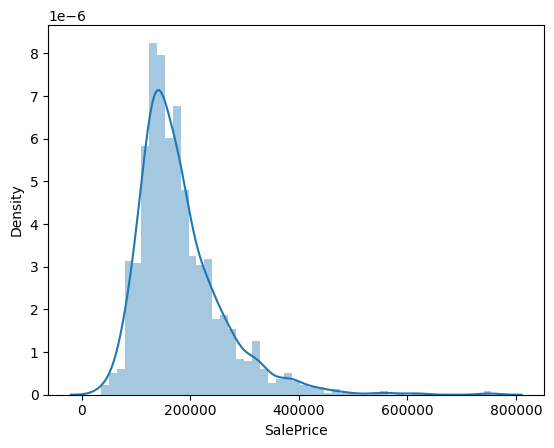

In [ ]:
#sns.distplot() : ヒストグラムとカーネル密度推定(KDE)を同時に描く関数
# KDE : ヒストグラムをもっとなめらかにしたグラフのようなもの
# しかし現在は非推奨の書き方
sns.distplot(df_train['SalePrice']);

In [ ]:
# 歪度(skewness)と尖度(kurtosis)
# 歪度：0に近い→左右対称、正→右に裾が長い、負→左に裾が長い
# 尖度：0に近い→正規分布と同じ尖具合、正→ピークが鋭い、負→平らな分布
print('Skewness: %f' % df_train['SalePrice'].skew())
print('Kurtosis: %f' % df_train['SalePrice'].kurt())

Skewness: 1.882876
Kurtosis: 6.536282


In [ ]:
var = 'GrLivArea'
data = pd.concat([df_train['SalePrice'], df_train[var]], axis=1)
data

,SalePrice,GrLivArea
0,208500,1710
1,181500,1262
2,223500,1786
3,140000,1717
4,250000,2198
...,...,...
1455,175000,1647
1456,210000,2073
1457,266500,2340
1458,142125,1078


<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

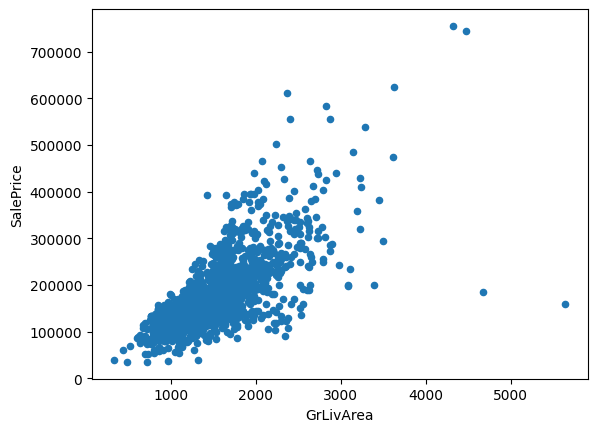

In [ ]:
data.plot.scatter(x=var, y='SalePrice')

<Axes: xlabel='TotalBsmtSF', ylabel='SalePrice'>

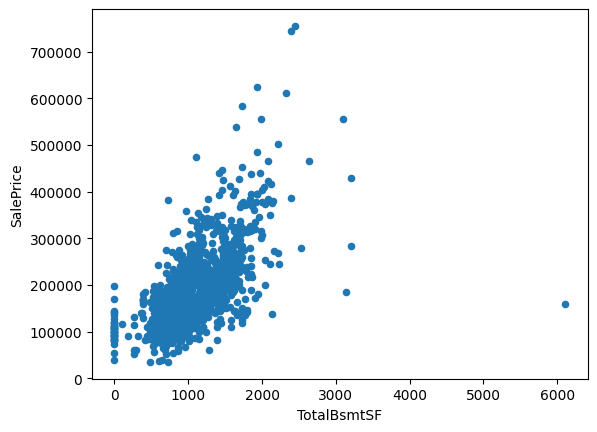

In [ ]:
var = 'TotalBsmtSF'
data = pd.concat([df_train['SalePrice'], df_train[var]], axis=1)
data.plot.scatter(x=var, y='SalePrice')

(np.float64(-0.5), np.float64(9.5), np.float64(0.0), np.float64(800000.0))

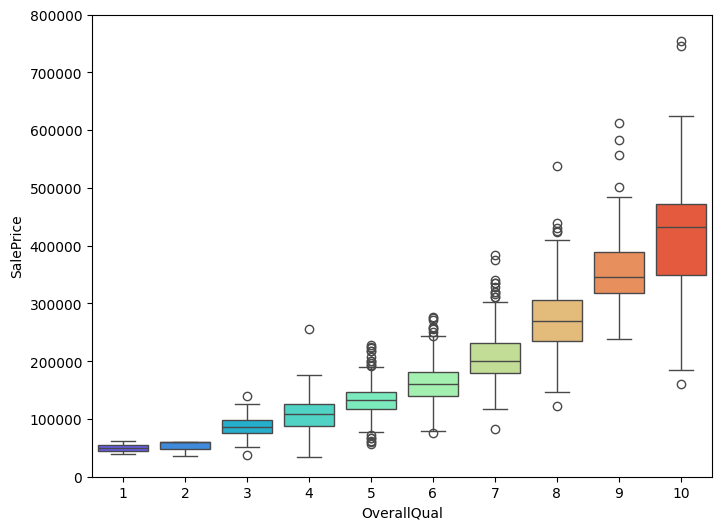

In [ ]:
var = 'OverallQual'
data = pd.concat([df_train['SalePrice'], df_train[var]], axis=1)
f, ax = plt.subplots(figsize=(8,6))
fig = sns.boxplot(
    x=var,
    y='SalePrice',
    data=data,
    palette='rainbow')
fig.axis(ymin=0, ymax=800000)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92,
  93,
  94,
  95,
  96,
  97,
  98,
  99,
  100,
  101,
  102,
  103,
  104,
  105,
  106,
  107,
  108,
  109,
  110,
  111],
 [Text(0, 0, '1872'),
  Text(1, 0, '1875'),
  Text(2, 0, '1880'),
  Text(3, 0, '1882'),
  Text(4, 0, '1885'),
  Text(5, 0, '1890'),
  Text(6, 0, '1892'),
  Text(7, 0, '1893'),
  Text(8, 0, '1898'),
  Text(9, 0, '1900'),
  Text(10, 0, '1904'),
  Text(11, 0, '1905'),
  Text(12, 0, '1906'),
  Text(13, 0, '1908'),
  Text(14, 0,

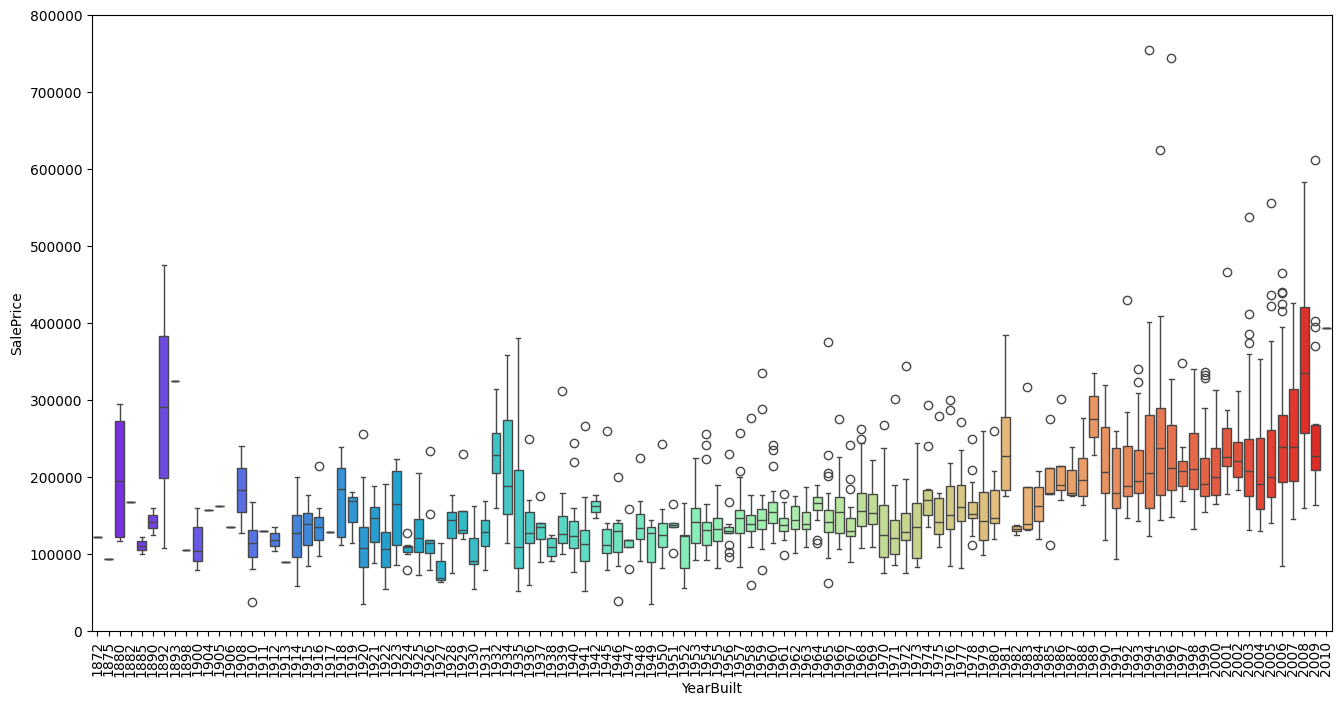

In [ ]:
var = 'YearBuilt'
data = pd.concat([df_train['SalePrice'], df_train[var]], axis=1)
f, ax = plt.subplots(figsize=(16,8))
fig = sns.boxplot(
    x=var,
    y='SalePrice',
    data=data,
    palette='rainbow'
)
fig.axis(ymin=0, ymax=800000)
plt.xticks(rotation=90)

In [ ]:
#var1 = 'OverallQual'
#var2 = 'YearBuilt'
#data_2 = pd.concat([df_train['SalePrice'], df_train[var1], df_train[var2]], axis=1)

#f, ax = plt.subplots(2, 1, figsize=(16,8))

#sns.boxplot(
    #data=data_2,
    #x=var1,
    #y='SalePrice',
    #palette='rainbow',
    #ax=ax[0]
    #)
#ax[0].set_title(var1)

#sns.boxplot(
    #data=data_2,
    #x=var2,
    #y='SalePrice',
    #palette='rainbow',
    #ax=ax[1]
#)
#ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=90)

In [ ]:
# <subplotsなし>
plt.figure(1)
plt.scatter(df_train[var1], df_train['SalePrice'])
plt.xlabel(var1)
plt.ylabel('SalePrice')
plt.title('matplotlib')
plt.show()

plt.figure(2)
data.plot.scatter(x=var1, y='SalePrice')
plt.title('pandas')
plt.show()

plt.figure(3)
sns.boxplot(
    data=data,
    x=var3,
    y='SalePrice',
    palette='rainbow'
)
plt.title('seaborn')
plt.show()

In [ ]:
# <subplotsあり>
fig, ax = plt.subplots(3,1,figsize=(8,16))

ax[0].scatter(df_train[var1], df_train['SalePrice'])
ax[0].set_xlabel(var1)
ax[0].set_ylabel('SalePrice')
ax[0].set_title('matplotlib')

data.plot.scatter(x=var2, y='SalePrice', ax=ax[1])
ax[1].set_title('pandas')

sns.boxplot(
    data=data,
    x=var3,
    y='SalePrice',
    palette='rainbow',
    ax=ax[2]
)
ax[2].set_title('seaborn')

# House Prices EDA

https://www.kaggle.com/code/dgawlik/house-prices-eda

In [ ]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import sklearn.linear_model as linear_model
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import KFold
from IPython.display import HTML, display
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:
url_train = 'https://raw.githubusercontent.com/ky106031/kaggle-datasets/main/house-prices-advanced-regression-techniques/train.csv'
url_test = 'https://raw.githubusercontent.com/ky106031/kaggle-datasets/main/house-prices-advanced-regression-techniques/test.csv'
train = pd.read_csv(url_train)
test = pd.read_csv(url_test)

In [ ]:
# 数値データとカテゴリカルデータを分ける
# != 'object' : 数値型（int, float）や日時型などを含む
# == 'object' : 文字列型

quantitative = [f for f in train.columns if train.dtypes[f] != 'object']
quantitative.remove('SalePrice')
quantitative.remove('Id')
qualitative = [f for f in train.columns if train.dtypes[f] == 'object']

<Axes: >

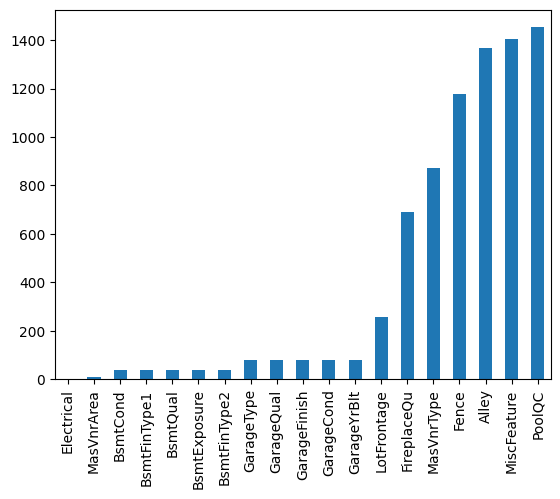

In [ ]:
missing = train.isnull().sum()
missing = missing[missing > 0]
missing.sort_values(inplace=True)
missing.plot.bar()

<Axes: title={'center': 'Log Normal'}, xlabel='SalePrice'>

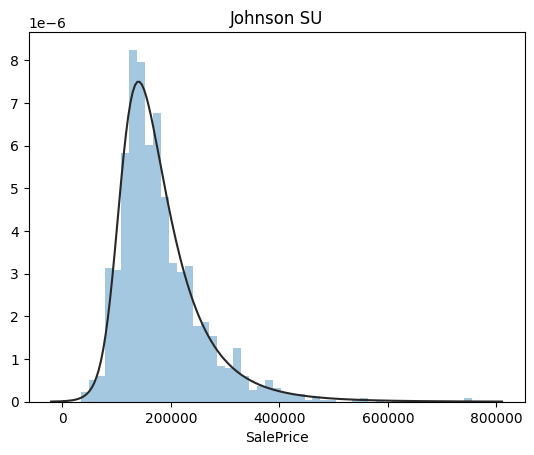

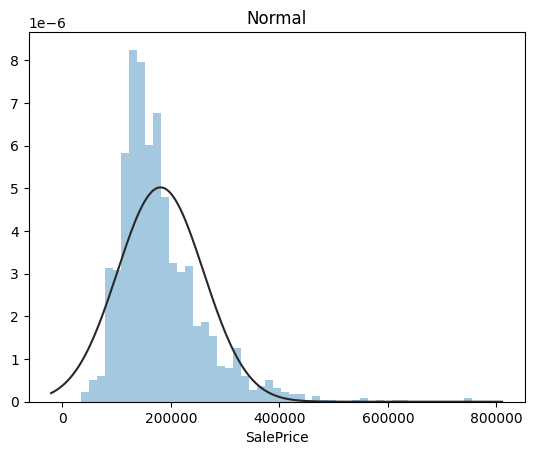

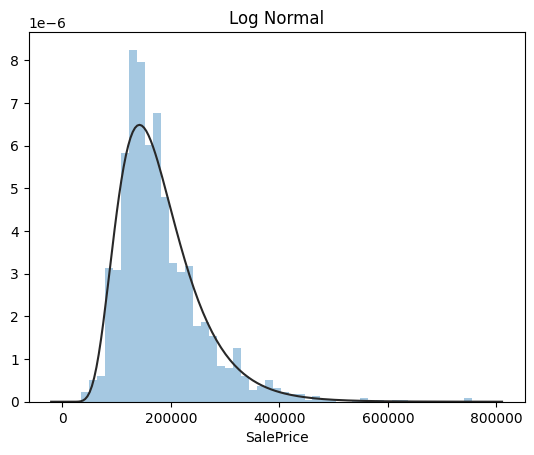

In [ ]:
#; → 同じ行で複数文を実行する記号、改行しても同じ

import scipy.stats as st
y = train['SalePrice']
plt.figure(1);plt.title('Johnson SU')
sns.distplot(y, kde=False, fit=st.johnsonsu)

plt.figure(2);plt.title('Normal')
sns.distplot(y, kde=False, fit=st.norm)

plt.figure(3);plt.title('Log Normal')
sns.distplot(y, kde=False, fit=st.lognorm)

In [ ]:
# 訓練データの数値データが正規分布かどうかを判定する

# stats.shapiro() : Shapiro-Wilk検定、戻り値は(統計量, p値)
# 無名関数 lambda 引数 : 戻り値の式
# True : 正規分布ではない、False : 正規分布っぽい
test_normality = lambda x : stats.shapiro(x.fillna(0))[1] < 0.01
normal = pd.DataFrame(train[quantitative])
normal = normal.apply(test_normality)

#any() : リストやseriesなどの中に１つでもTrueがあればTrueを返す関数
# normal.any()
# → シリーズ中に True が1つでもあれば True を返す。
# → つまり「1つでも正規分布ではない列があるか」を判定。
# not normal.any()
# → その論理値を反転。
# → 「すべて正規分布に従っているか？」を意味する。
# 「すべての数値列が正規分布に従うなら True、1つでも従わない列があれば False」
print(not normal.any())

False


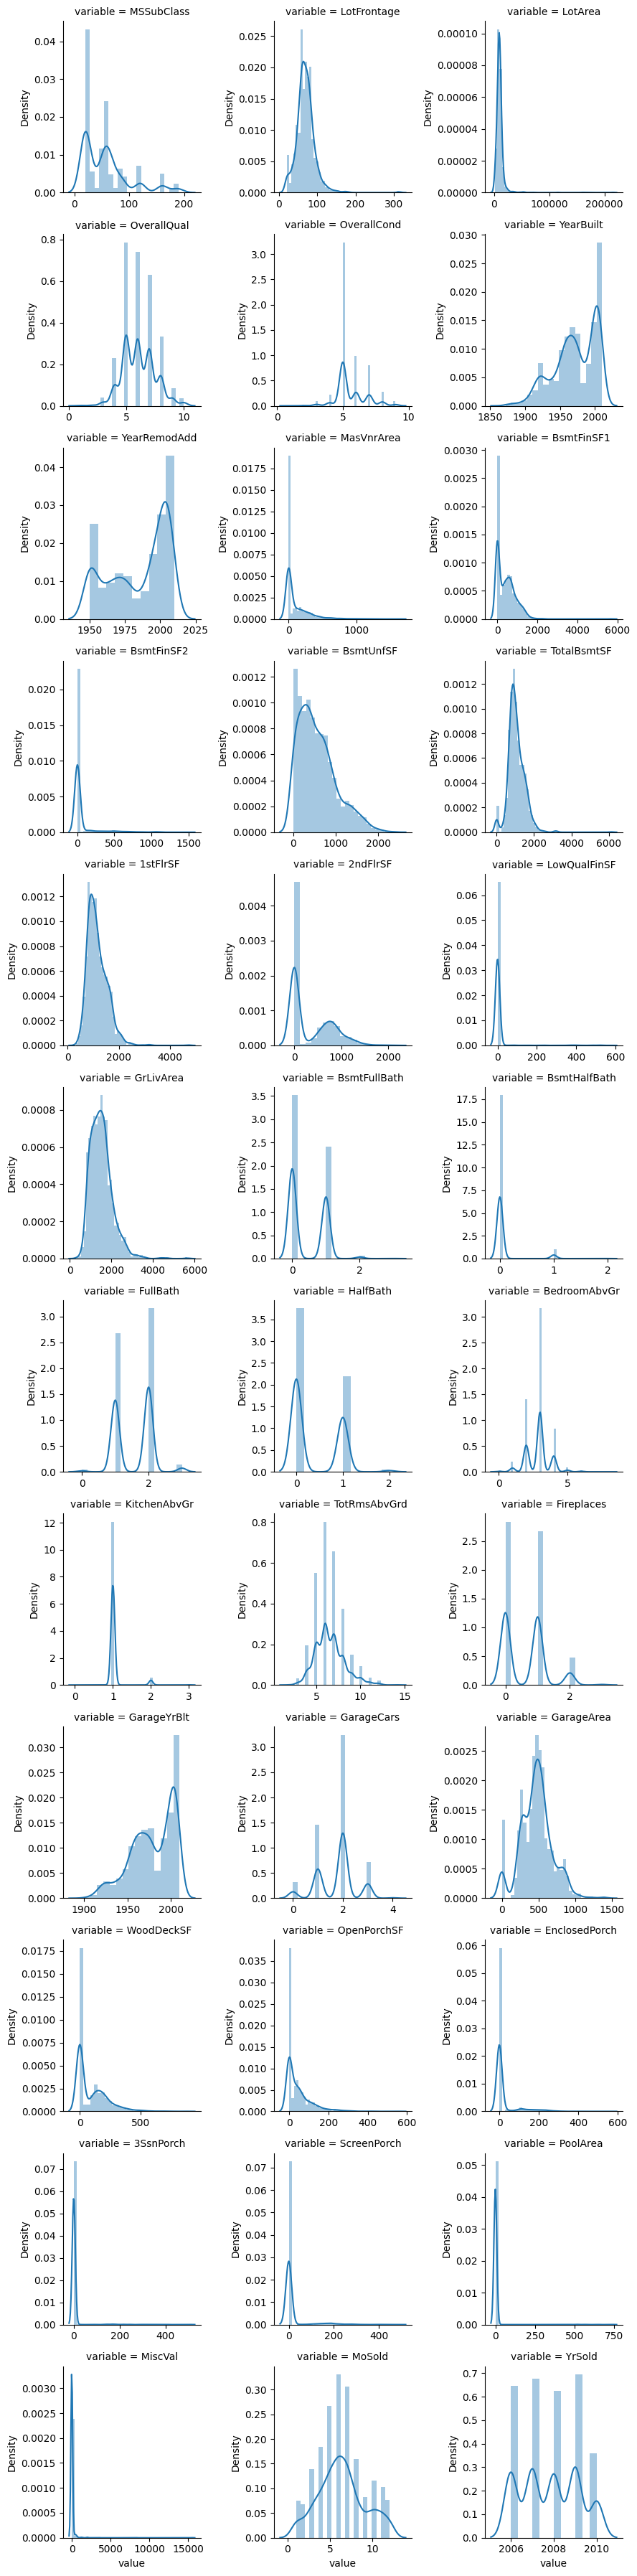

In [ ]:
# quantitative に入っている列（数値型の特徴量）だけを選択してmelt（一列）
f = pd.melt(train, value_vars=quantitative)


g = sns.FacetGrid(
    f,
    col='variable', # variable 列ごとにグラフを作る
    col_wrap=3,     # 横に2列並べる
    sharex=False,   # x軸は変数ごとに独立
    sharey=False   # y軸は変数ごとに独立
    )

g = g.map(sns.distplot, 'value')

In [ ]:
f = pd.melt(train, id_vars='SalePrice', value_vars=quantitative)

# ③ FacetGridを作成
g = sns.FacetGrid(
    f,
    col='variable',  # 各特徴量ごとにグラフ
    col_wrap=3,      # 横3列で折り返す
    sharex=False,    # 軸を独立に
    sharey=False
)

# ④ 各特徴量とSalePriceの散布図を描く
g.map(sns.scatterplot, 'value', 'SalePrice')

In [ ]:
f

,variable,value
0,MSSubClass,60.0
1,MSSubClass,20.0
2,MSSubClass,60.0
3,MSSubClass,70.0
4,MSSubClass,60.0
...,...,...
52555,YrSold,2007.0
52556,YrSold,2010.0
52557,YrSold,2010.0
52558,YrSold,2010.0


In [ ]:
#Categorical data

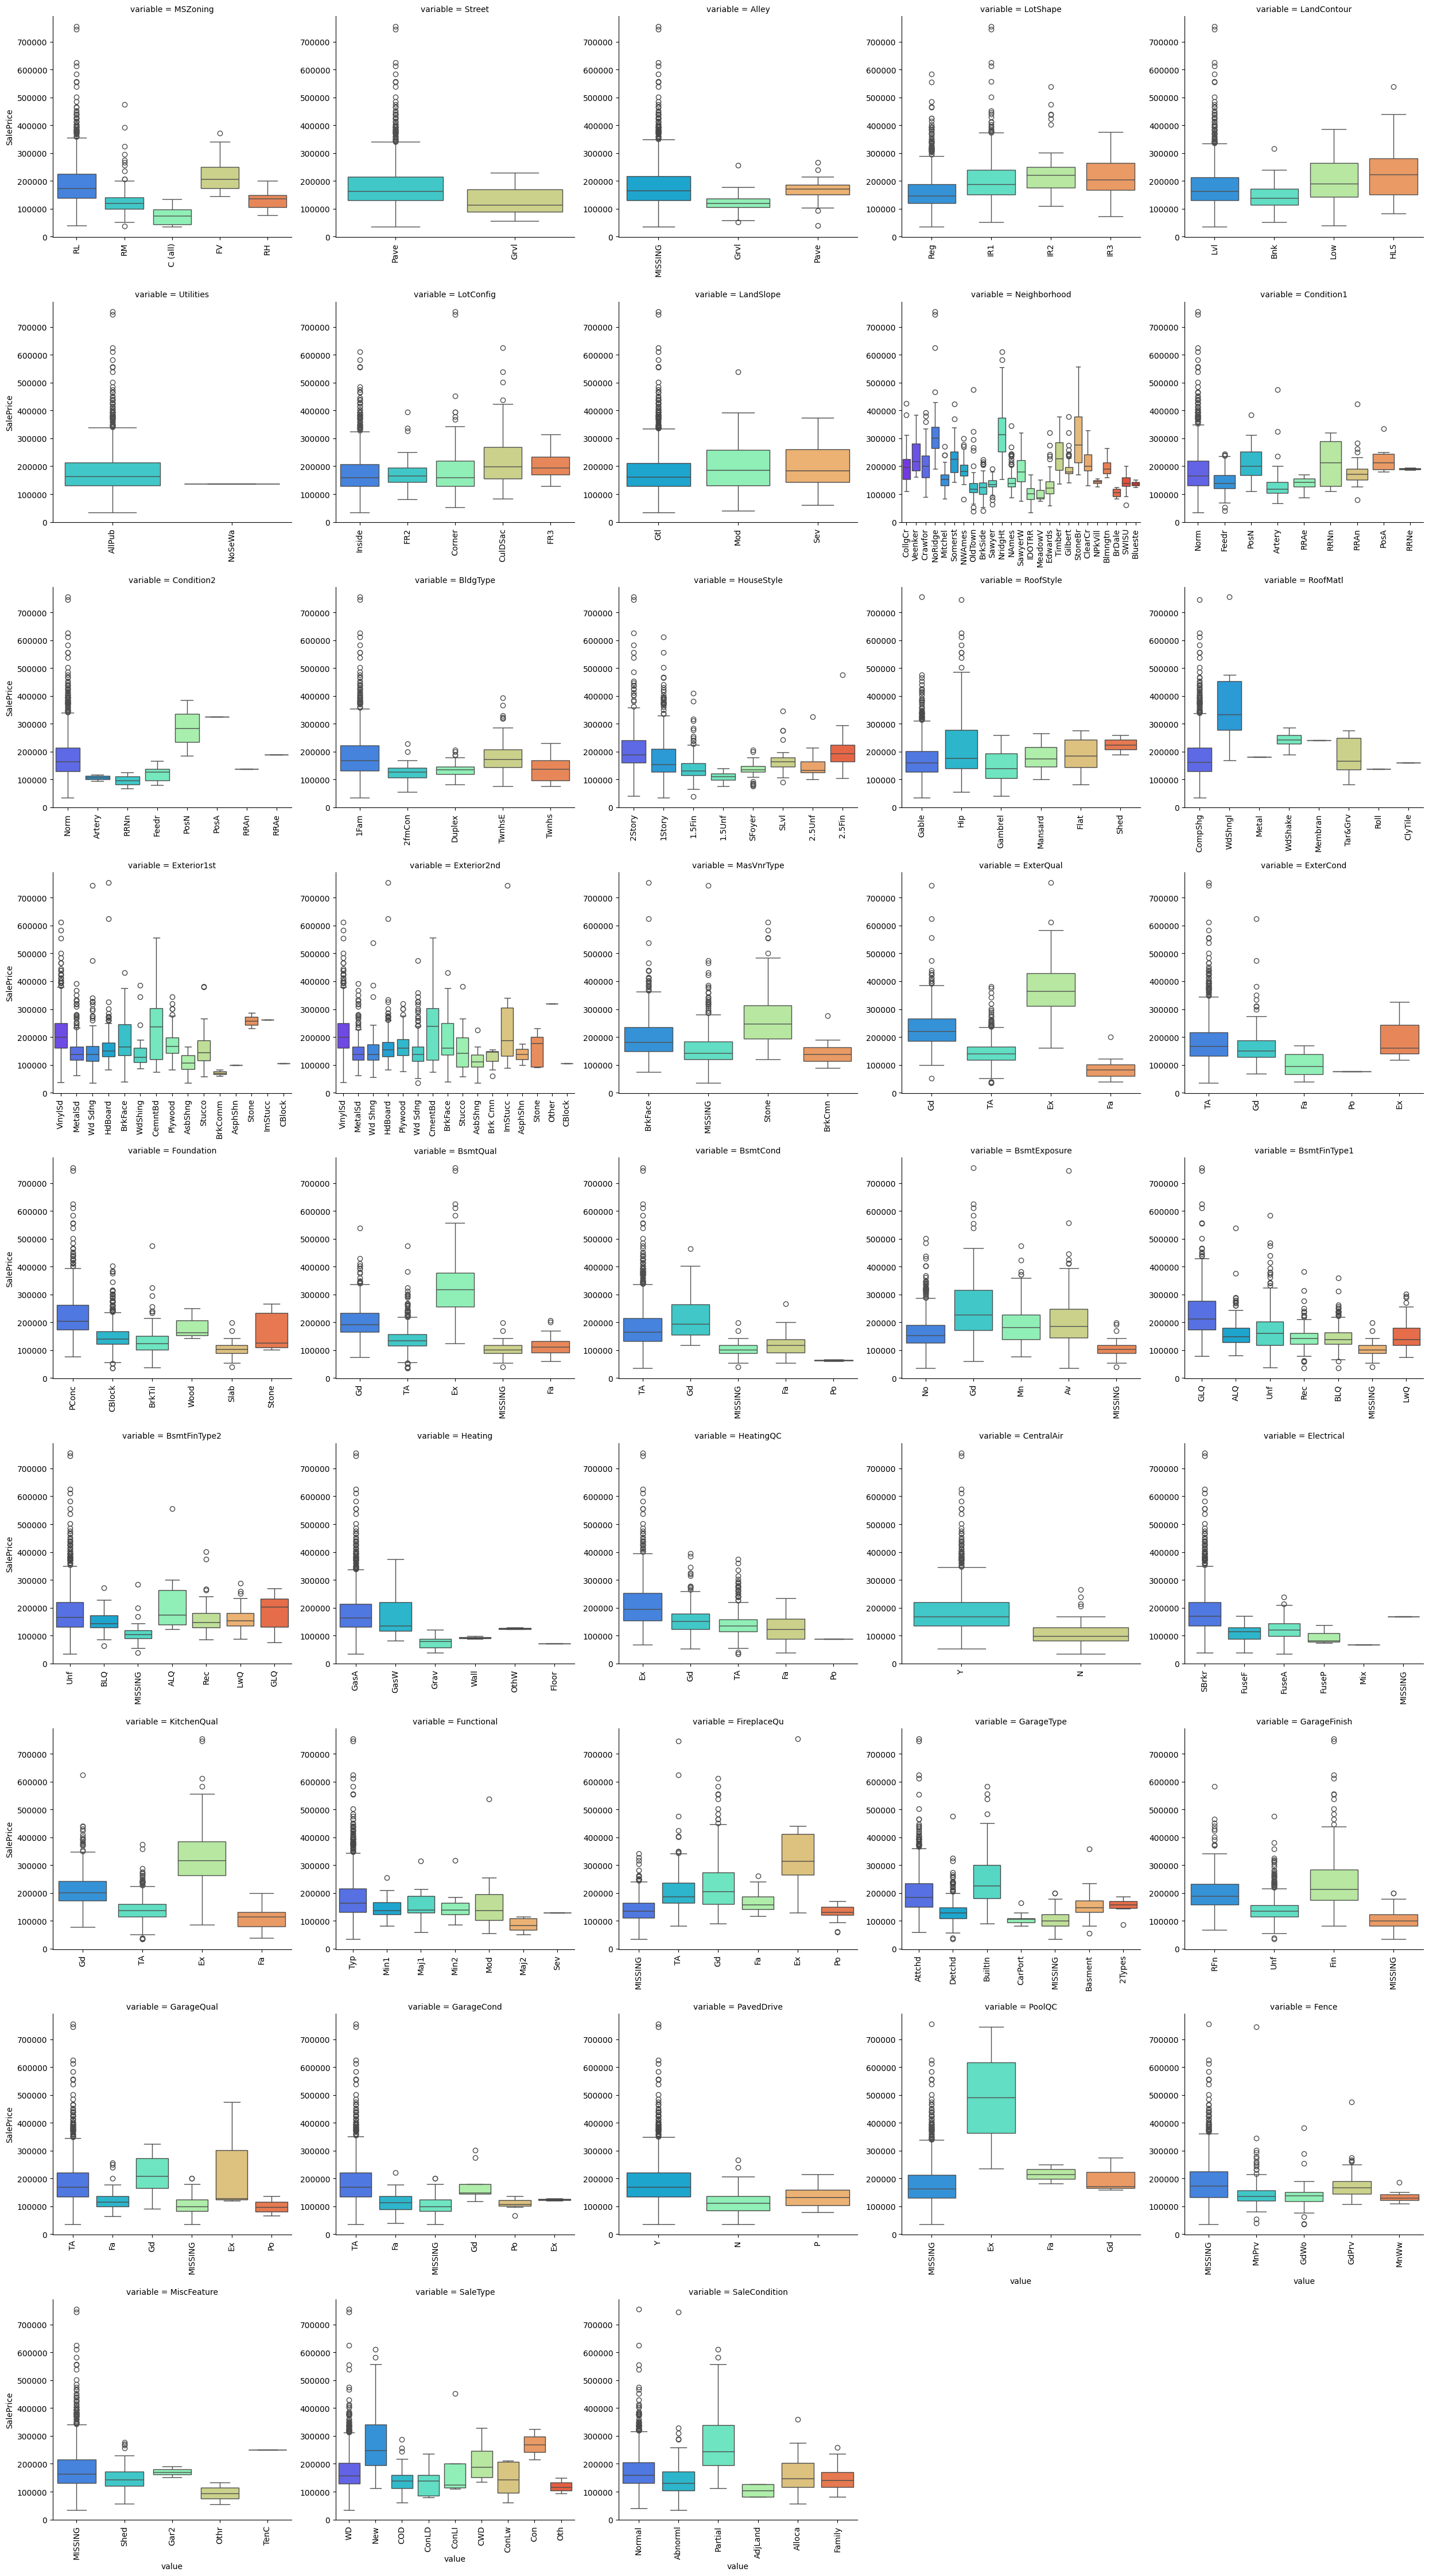

In [ ]:
for c in qualitative:
    train[c] = train[c].astype('category')
    if train[c].isnull().any():
        train[c] = train[c].cat.add_categories(['MISSING'])
        train[c] = train[c].fillna('MISSING')

# **kwargs : キーワード引数をまとめて受け取るという意味
def boxplot(x, y, **kwargs):
    sns.boxplot(x=x, y=y, palette='rainbow')
    x=plt.xticks(rotation=90)

f = pd.melt(train, id_vars=['SalePrice'], value_vars=qualitative)
g = sns.FacetGrid(f,
                  col="variable",
                  col_wrap=5,
                  sharex=False,
                  sharey=False,
                  height=5)
g = g.map(boxplot, "value", "SalePrice")

In [ ]:
f

,SalePrice,variable,value
0,208500,MSZoning,RL
1,181500,MSZoning,RL
2,223500,MSZoning,RL
3,140000,MSZoning,RL
4,250000,MSZoning,RL
...,...,...,...
62775,175000,SaleCondition,Normal
62776,210000,SaleCondition,Normal
62777,266500,SaleCondition,Normal
62778,142125,SaleCondition,Normal


In [ ]:
# 各カテゴリ変数が、住宅価格（SalePrice）に与える影響を分散分析（ANOVA）で数値的に評価し、影響度の強い変数を棒グラフで可視化
# 分散分析：「グループ間の平均値に統計的な差があるか」を調べるための手法
# 例：カテゴリ変数「ExterQual（外装品質：Ex,Gd,TA,Fa,...）」について、
# →各カテゴリのSalePriceの平均が本当に異なると言えるのか？単なるばらつきではなく統計的に有意な差があるか？

# p値が小さい → SalePriceに差がある
# 「カテゴリの値によって価格に差があるか？」を調べたいとき、分散分析は最適
# 特に3つ以上のカテゴリ値がある場合（例：Ex, Gd, TA, Fa）に効果的

def anova(frame):
  anv = pd.DataFrame()  # 結果を入れるためのからのDataFrame
  anv['feature'] = qualitative  #分析対象のカテゴリ変数（リストqualitative）をそのまま入れる
  pvals = []  # これから求めるp値を順番に入れるリスト

  # 各カテゴリ変数に対してループ
  for c in qualitative:
    samples = []
    for cls in frame[c].unique():  # cls はその変数cの中に出てくる値(例:Ex,Gd,TA,Fa,...)
      # そのカテゴリに属する行だけを抽出し、SalePrice の値を取得
      # s はそのカテゴリの住宅価格リスト（NumPy配列）
      # それを samples に追加していく
      s = frame[frame[c] == cls]['SalePrice'].values
      samples.append(s)
    pval = stats.f_oneway(*samples)[1]  # stats.f_oneway() : 一元配置分散分析を実行、戻り値は(F値, p値)
    pvals.append(pval)

  anv['pval'] = pvals # 順番はqualitativeに対応
  return anv.sort_values('pval')

In [ ]:
# 各カテゴリ変数がSalePriceにどれくらい影響していそうかをANOVAで評価
a = anova(train)
a

,feature,pval
8,Neighborhood,1.558600e-225
18,ExterQual,1.439551e-204
21,BsmtQual,8.158548e-196
30,KitchenQual,3.032213e-192
34,GarageFinish,6.228747e-115
32,FireplaceQu,2.971217e-107
20,Foundation,5.791895e-91
33,GarageType,6.117026e-87
24,BsmtFinType1,2.386358e-71
27,HeatingQC,2.667062e-67


In [ ]:
a['disparty'] = np.log(1./a['pval'].values)
a

,feature,pval,disparty
8,Neighborhood,1.558600e-225,517.637858
18,ExterQual,1.439551e-204,469.363028
21,BsmtQual,8.158548e-196,449.207612
30,KitchenQual,3.032213e-192,440.987045
34,GarageFinish,6.228747e-115,262.968110
32,FireplaceQu,2.971217e-107,245.287633
20,Foundation,5.791895e-91,207.778784
33,GarageType,6.117026e-87,198.513827
24,BsmtFinType1,2.386358e-71,162.613773
27,HeatingQC,2.667062e-67,153.292224


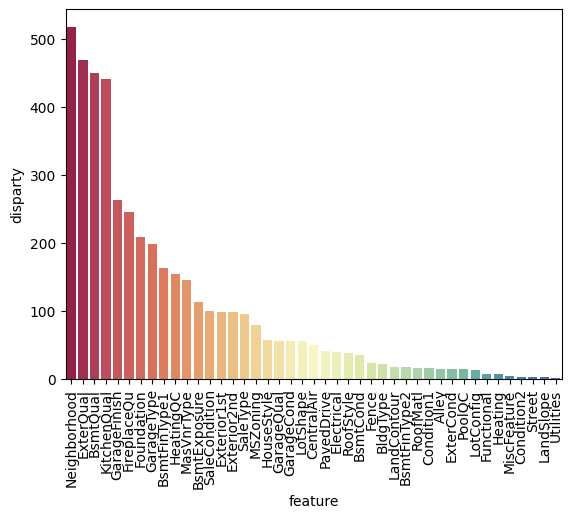

In [ ]:
sns.barplot(data=a,
            x='feature',
            y='disparty',
            palette='Spectral'
            )
x = plt.xticks(rotation=90)

In [ ]:
# カテゴリ変数を「価格との関係性に基づいて数値に変換（エンコード）」する
# → 価格に影響の強いカテゴリをうまくモデルに使えるように順序つき数値に変換する

# カテゴリ変数を価格の平均値順に並べて
# それを1,2,3...といった連番でエンコードして
# 新しい列(feature_E)としてDataFrameに追加

def encode(frame, feature):
  # val列にカテゴリのユニークな値を取り出して、
  ordering = pd.DataFrame()
  ordering['val'] = frame[feature].unique()
  # それをインデックスにしたordering DataFrameを作成
  ordering.index = ordering.val

  # 各カテゴリごとのSalePriceの平均を求める
  # → 指定されたカテゴリ変数でグルーピングして、平均価格（spmean）を求めて列に追加
  ordering['spmean'] = frame[[feature, 'SalePrice']].groupby(feature).mean()['SalePrice']

  # 価格の小さい順に並び替え、順序番号をつける
  # → 平均価格が低い順に並べて、1,2,3,...と順番を割り当てる
  ordering = ordering.sort_values('spmean')
  ordering['ordering'] = range(1, ordering.shape[0]+1)

  #辞書に変換
  ordering = ordering['ordering'].to_dict()

  # 元のデータに数値として追加
  for cat, o in ordering.items():
    frame.loc[frame[feature] == cat, feature+'_E'] = o

In [ ]:
qual_encoded = []
for q in qualitative:
  encode(train, q)
  qual_encoded.append(q+'_E')
print(qual_encoded)

['MSZoning_E', 'Street_E', 'Alley_E', 'LotShape_E', 'LandContour_E', 'Utilities_E', 'LotConfig_E', 'LandSlope_E', 'Neighborhood_E', 'Condition1_E', 'Condition2_E', 'BldgType_E', 'HouseStyle_E', 'RoofStyle_E', 'RoofMatl_E', 'Exterior1st_E', 'Exterior2nd_E', 'MasVnrType_E', 'ExterQual_E', 'ExterCond_E', 'Foundation_E', 'BsmtQual_E', 'BsmtCond_E', 'BsmtExposure_E', 'BsmtFinType1_E', 'BsmtFinType2_E', 'Heating_E', 'HeatingQC_E', 'CentralAir_E', 'Electrical_E', 'KitchenQual_E', 'Functional_E', 'FireplaceQu_E', 'GarageType_E', 'GarageFinish_E', 'GarageQual_E', 'GarageCond_E', 'PavedDrive_E', 'PoolQC_E', 'Fence_E', 'MiscFeature_E', 'SaleType_E', 'SaleCondition_E']


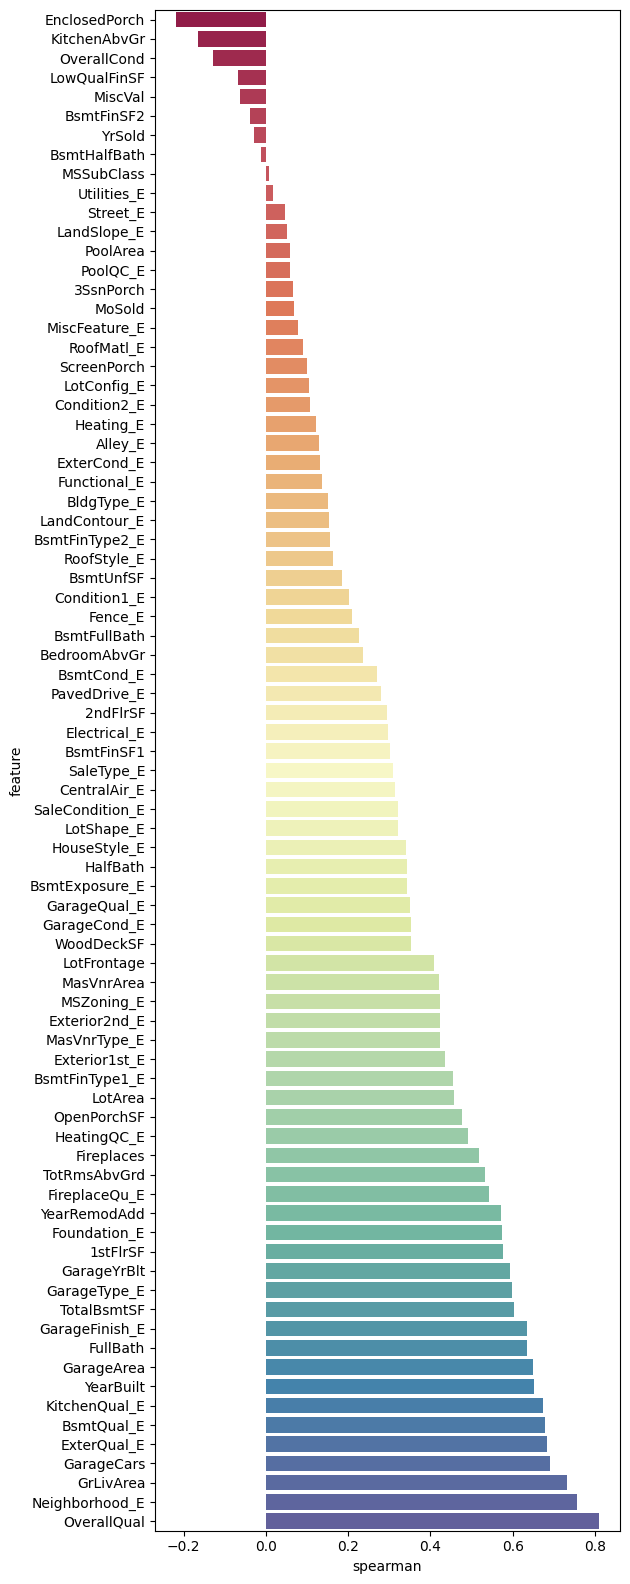

In [ ]:
def spearman(frame, features):
    spr = pd.DataFrame()
    spr['feature'] = features
    spr['spearman'] = [frame[f].corr(frame['SalePrice'], 'spearman') for f in features]
    spr = spr.sort_values('spearman')
    plt.figure(figsize=(6, 0.25*len(features)))
    sns.barplot(data=spr, y='feature', x='spearman', orient='h', palette='Spectral')

features = quantitative + qual_encoded
spearman(train, features)

<Axes: >

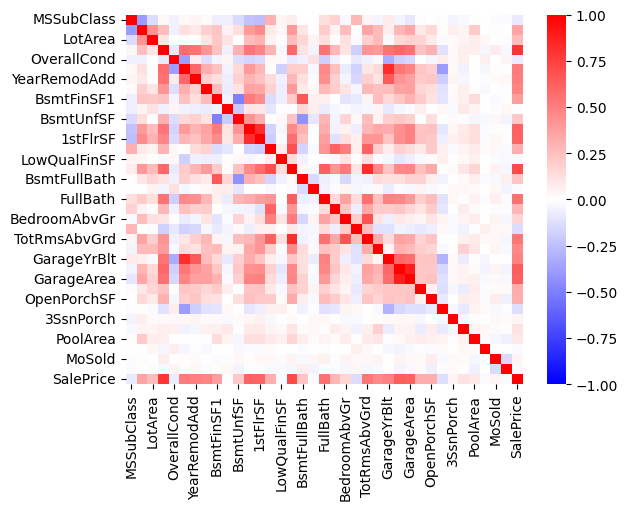

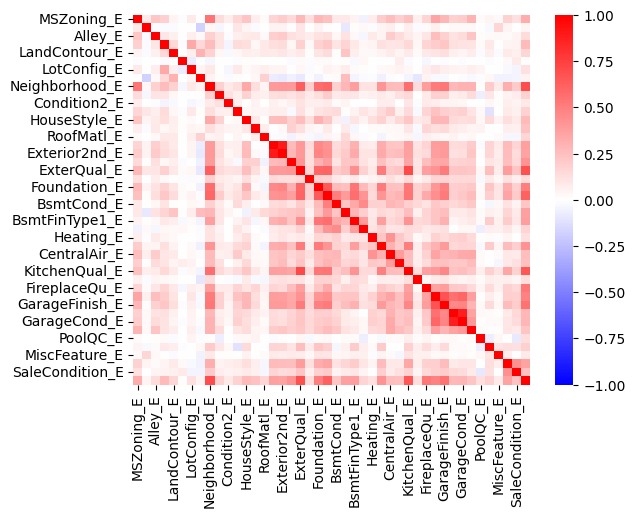

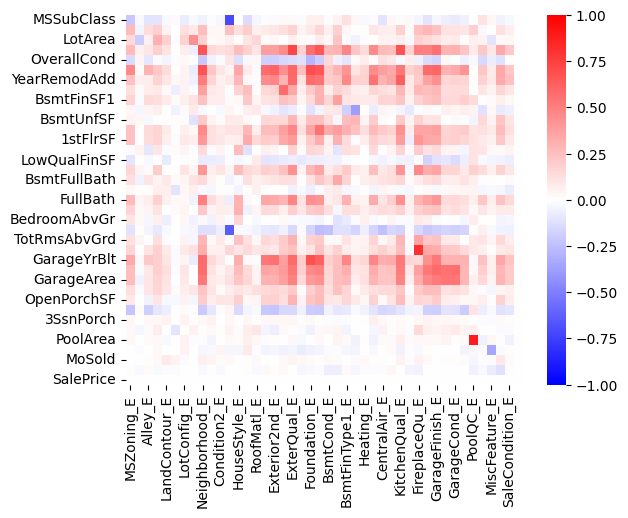

In [ ]:
# 数値データ
plt.figure(1)
corr = train[quantitative+['SalePrice']].corr()
sns.heatmap(corr, cmap='bwr', vmin=-1, vmax=1)

# カテゴリ変数を数値化したデータ
plt.figure(2)
corr = train[qual_encoded+['SalePrice']].corr()
sns.heatmap(corr, cmap='bwr', vmin=-1, vmax=1)

# 数値データとカテゴリデータ
# 相関行列を0で初期化して、forループで１つずつ計算
plt.figure(3)
corr = pd.DataFrame(np.zeros([len(quantitative)+1, len(qual_encoded)+1]),
                    index = quantitative+['SalePrice'],
                    columns = qual_encoded+['SalePrice'])
for q1 in quantitative:
  for q2 in qual_encoded:
    corr.loc[q1, q2] = train[q1].corr(train[q2])
sns.heatmap(corr, cmap='bwr', vmin=-1, vmax=1)

In [ ]:
plt.colormaps()

['magma',
 'inferno',
 'plasma',
 'viridis',
 'cividis',
 'twilight',
 'twilight_shifted',
 'turbo',
 'berlin',
 'managua',
 'vanimo',
 'Blues',
 'BrBG',
 'BuGn',
 'BuPu',
 'CMRmap',
 'GnBu',
 'Greens',
 'Greys',
 'OrRd',
 'Oranges',
 'PRGn',
 'PiYG',
 'PuBu',
 'PuBuGn',
 'PuOr',
 'PuRd',
 'Purples',
 'RdBu',
 'RdGy',
 'RdPu',
 'RdYlBu',
 'RdYlGn',
 'Reds',
 'Spectral',
 'Wistia',
 'YlGn',
 'YlGnBu',
 'YlOrBr',
 'YlOrRd',
 'afmhot',
 'autumn',
 'binary',
 'bone',
 'brg',
 'bwr',
 'cool',
 'coolwarm',
 'copper',
 'cubehelix',
 'flag',
 'gist_earth',
 'gist_gray',
 'gist_heat',
 'gist_ncar',
 'gist_rainbow',
 'gist_stern',
 'gist_yarg',
 'gnuplot',
 'gnuplot2',
 'gray',
 'hot',
 'hsv',
 'jet',
 'nipy_spectral',
 'ocean',
 'pink',
 'prism',
 'rainbow',
 'seismic',
 'spring',
 'summer',
 'terrain',
 'winter',
 'Accent',
 'Dark2',
 'Paired',
 'Pastel1',
 'Pastel2',
 'Set1',
 'Set2',
 'Set3',
 'tab10',
 'tab20',
 'tab20b',
 'tab20c',
 'grey',
 'gist_grey',
 'gist_yerg',
 'Grays',
 'magma_r',

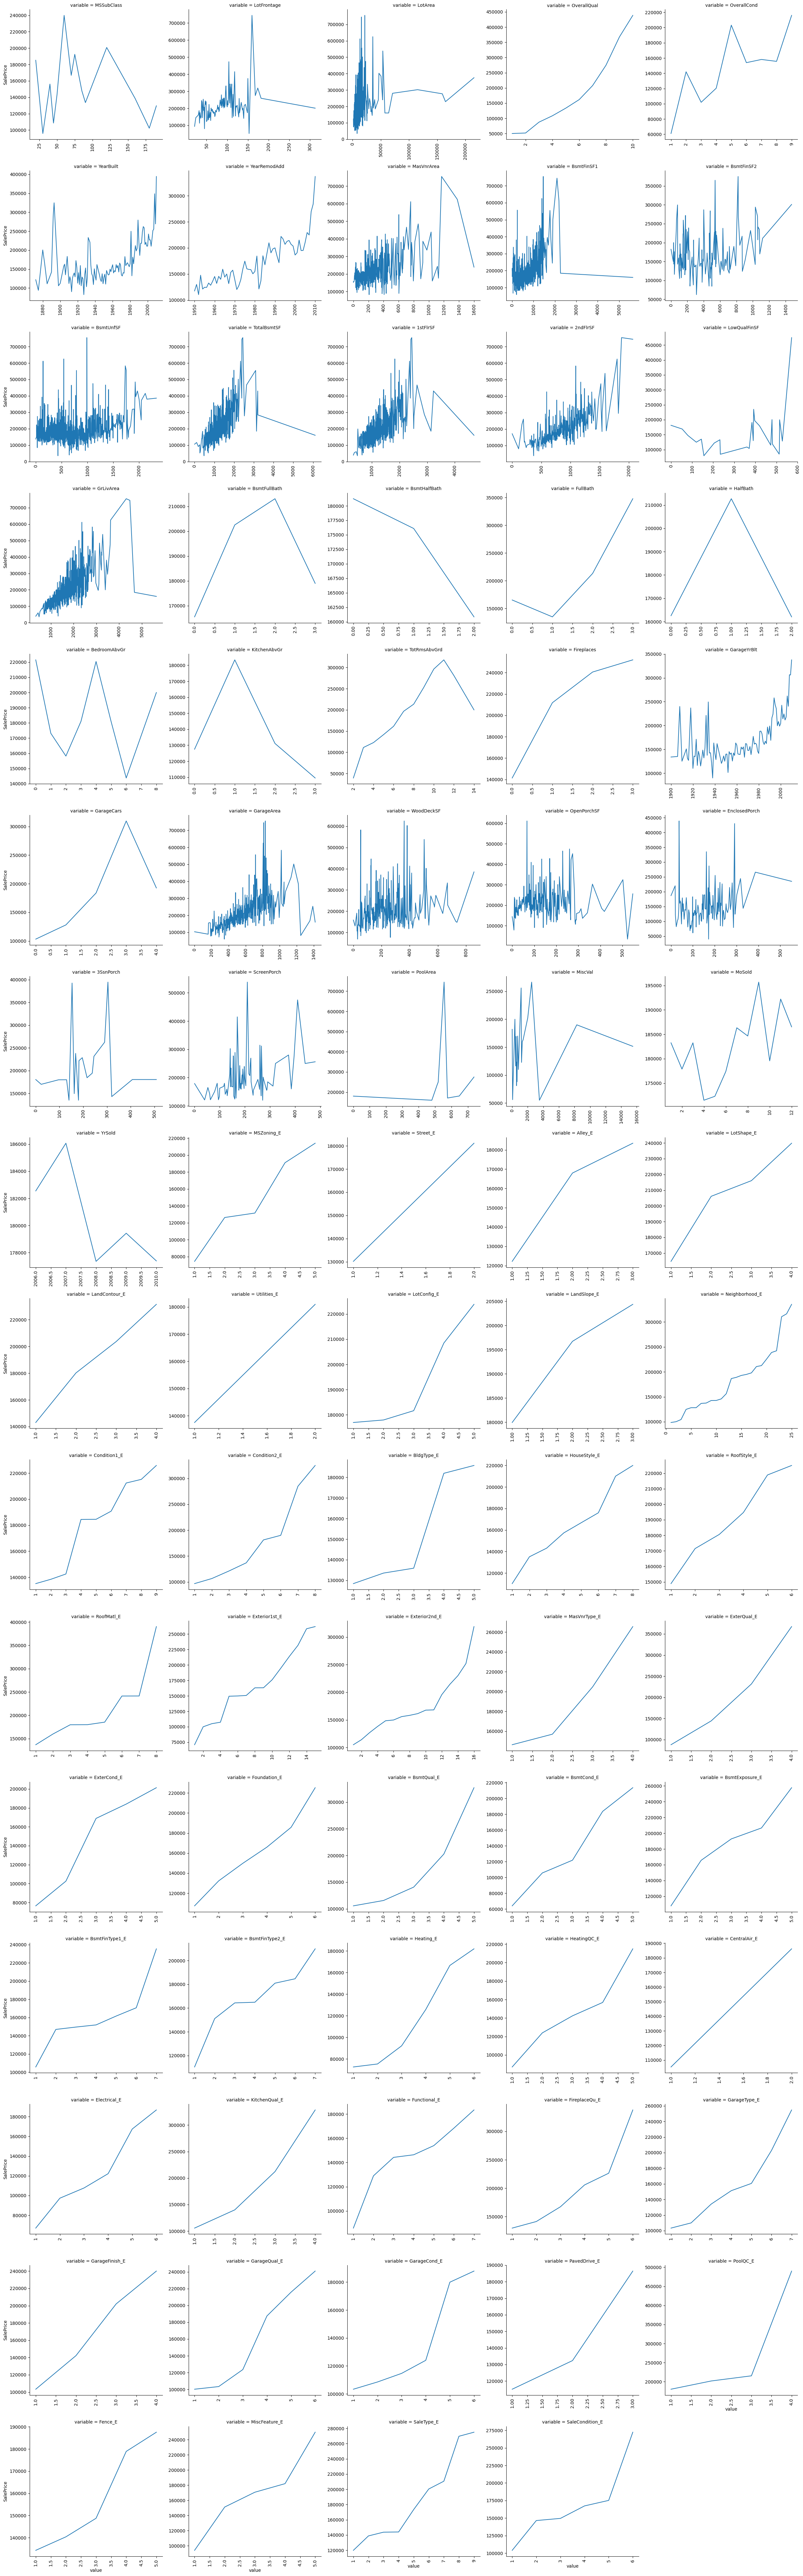

In [ ]:
# 複数の特徴量に対して、「値ごとのSalePriceの平均値の折れ線グラフ」をまとめて書く
# 各特徴料とSalePriceの関係を時系列的な折線のように直感的に可視化する
# →「各特徴量の値ごとに平均的に価格がどう変わるか」を折れ線グラフでまとめて見る

def pairplot(x, y, **kwargs):
  # plt.gca() : get current axes → 現在の座標軸を取得 → つまり、今描画中のサブプロットを取得する関数
  ax = plt.gca()
  # x軸には特徴量の値、y軸にはその値に対応する平均SalePrice → 値と価格の関係が直感的にわかる
  ts = pd.DataFrame({'time':x, 'val':y})
  ts = ts.groupby('time').mean()
  ts.plot(ax=ax)
  plt.xticks(rotation=90)

f = pd.melt(train, id_vars=['SalePrice'], value_vars=quantitative+qual_encoded)

# FacetGridでサブプロットを作る
g = sns.FacetGrid(
    f,
    col='variable',
    col_wrap=5,
    sharex=False,
    sharey=False,
    height=5
)

g = g.map(pairplot, 'value', 'SalePrice')

In [ ]:
def pairplot(x, y, **kwargs):
  ts = pd.DataFrame({'time':x, 'val':y})
  ts = ts.groupby('time').mean()
  sns.lineplot(
      data=ts,
      x='time',
      y='val',
      #marker='o',
      #color='red'
  )
  plt.xticks(rotation=90)

f = pd.melt(train, id_vars=['SalePrice'], value_vars=quantitative+qual_encoded)

g = sns.FacetGrid(
    f,
    col='variable',
    col_wrap=5,
    sharex=False,
    sharey=False,
    height=5
    )

g = g.map(pairplot, 'value', 'SalePrice')

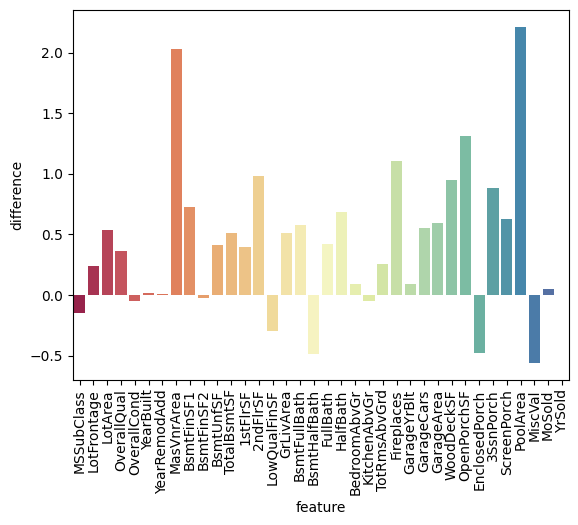

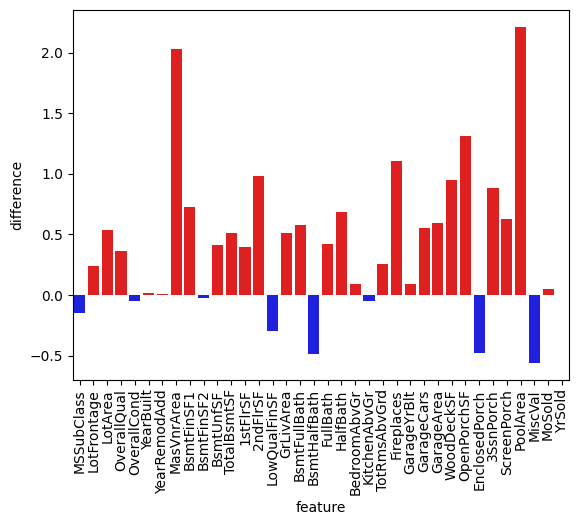

In [ ]:
# 安い家（<200,000）と高い家（>=200,000）の数値特徴量の平均値の違いを比較
# 価格帯によって数値特徴量がどれだけ変わるかを、相対的な割合で棒グラフにして可視化
# → 高い家はどんな特徴量が大きい/小さいか？

# 数値特徴量だけを対象に分析
features = quantitative

standard = train[train['SalePrice'] < 200000] # 安めの家
pricy = train[train['SalePrice'] >= 200000] # 高めの家

diff = pd.DataFrame()
diff['feature'] = features

# standardの平均で割る → standardと比べて高い家がどのくらい高いか
# 0.5 → 高い家は安い家より50%大きい
# -0.2 → 高い家は安い家より20%小さい
diff['difference'] = [
    (pricy[f].fillna(0.).mean() - standard[f].fillna(0.).mean()) / standard[f].fillna(0.).mean() for f in features
]

plt.figure(1)
sns.barplot(
    data=diff,
    x='feature',
    y='difference',
    palette='Spectral'
)
x = plt.xticks(rotation=90)

# 差の大きさで色分け：プラスなら赤、マイナスなら青
plt.figure(2)
diff['color'] = diff['difference'].apply(lambda x: 'red' if x > 0 else 'blue')
sns.barplot(
    data=diff,
    x='feature',
    y='difference',
    palette=diff['color'].tolist()
    )
x = plt.xticks(rotation=90)

In [ ]:
# clustering
# 住宅の特徴から似たもの同士をクラスタリングし、t-SNEで可視化

features = quantitative + qual_encoded
model = TSNE(n_components=2, random_state=0, perplexity=50)
# .values : Numpy配列に変換
# →pandasの表(DataFrameやSeries)から純粋な数値データだけをNumpy形式で取り出すもの
# 必ずしも必要というわけではないが、t-SNEやPCAに渡すときはあると安心かつ、場合によっては必要
# t-SNEやPCAは内部的にNumpy配列を前提に最適化されているため、明示的に.valuesを使っておくとエラーを防ぎやすい
# .to_numpy()でも可
X = train[features].fillna(0).values

tsne = model.fit_transform(X)

<Axes: >

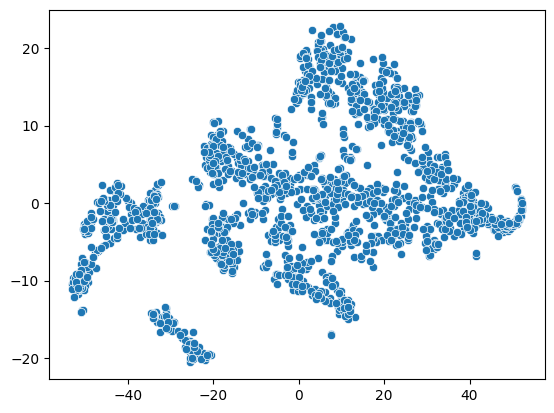

In [ ]:
sns.scatterplot(x=tsne[:,0], y=tsne[:,1])

In [ ]:
# PCAと標準化

std = StandardScaler()
s = std.fit_transform(X)

pca = PCA(n_components=30)
pca.fit(s)
pc = pca.fit_transform(s)

kmeans = KMeans(n_clusters=5)
kmeans.fit(pc)

KMeans(n_clusters=5)

0.7516846874028447


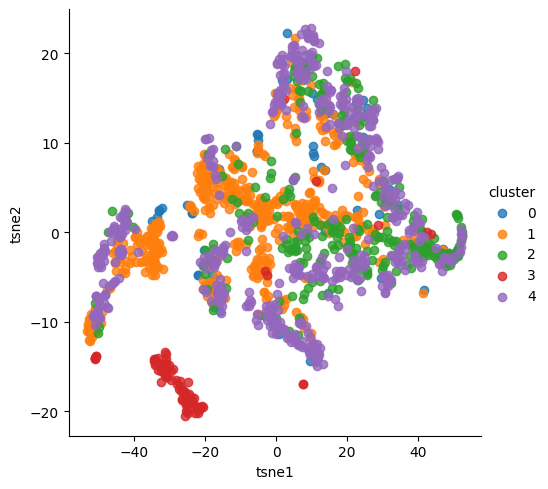

In [ ]:
# t-SNE座標 + クラスタラベルをDataFrameにまとめる

fr = pd.DataFrame({'tsne1': tsne[:,0], 'tsne2': tsne[:, 1], 'cluster': kmeans.labels_})

# sns.lmplot() : 散布図を描き、その上に回帰直線を重ねてくれる関数
sns.lmplot(
    data=fr,
    x='tsne1',
    y='tsne2',
    hue='cluster',
    fit_reg=False
)

# PCAで説明された分散の割合を確認
print(np.sum(pca.explained_variance_ratio_))

# t-SNEの結果で可視化しているのに、クラスタリングはPCA上でやっている理由
# → t-SNEの座標は「クラスタリングに使うには適さない」から
# t-SNEの利点として、「非線形な関係を保ったまま可視化できる」「近いものは近く/遠いものは遠くに配置」「人間が見て直感的に理解できる可視化」
# t-SNEの欠点として、「グローバルな距離は保存しない（クラスタ間の距離に意味はない）」「ランダム性がある」「座標値自体に意味はなく、クラスタリングに不安定」

# PCAは線形次元削減なので、元の特徴量の「分散をできるだけ保った」低次元表現が得られる
# 座標軸の数値に意味があり、距離や角度の解釈もしやすい
# → クラスタリングの前処理に適している

# 「PCAでクラスタリング → t-SNEで可視化」の理由
# PCA : 情報を保った低次元空間でKMeansを安定して実行
# KMeans : クラスタリング
# t-SNE : 結果を人が見やすい図にする

<Axes: ylabel='Density'>

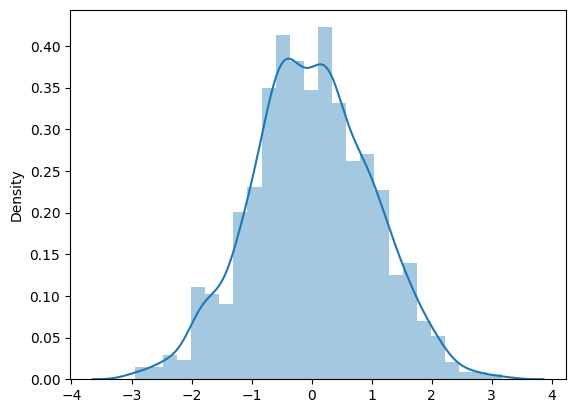

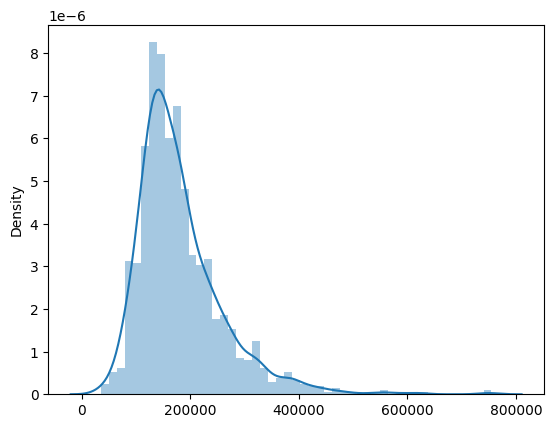

In [ ]:
# Johnson SU分布を使って、SalePriceを正規分布に近づける
# また、逆変換で元に戻せることを確認

y = train['SalePrice'].values
def johnson(y):
    gamma, eta, epsilon, lbda = stats.johnsonsu.fit(y)
    yt = gamma + eta*np.arcsinh((y-epsilon)/lbda)
    return yt, gamma, eta, epsilon, lbda

def johnson_inverse(y, gamma, eta, epsilon, lbda):
    return lbda*np.sinh((y-gamma)/eta) + epsilon

yt, g, et, ep, l = johnson(y)
yt2 = johnson_inverse(yt, g, et, ep, l)
plt.figure(1)
sns.distplot(yt)
plt.figure(2)
sns.distplot(yt2)

In [ ]:
# Regression

# 評価関数
def error(actual, predicted):
  actual = np.log(actual)
  predicted = np.log(predicted)
  return np.sqrt(np.sum(np.square(actual - predicted))/len(actual))

# 対数変換
# np.log1p(x) = np.log(x+1)
# 対数変換は、右に裾の長い分布を正規分布に近づける
def log_transform(feature):
  train[feature] = np.log1p(train[feature].values)

# 二乗特徴量の生成
# 線形回帰分析に、非線形関係を1時モデルでも表現できるようになる
# ・線形回帰モデルに２乗特徴量を加えると、直線的な関係だけでなく「曲線的な関係」も学習できるようになる
# ・２乗する前の特徴量と強い相関を持つので多重共線性を引き起こしやすい→そのため正則化（Lasso/Ridge）を使うことが望ましい
# 　→使わなくても解は出るが、係数の不安定性や解釈の難しさが増すため、実務的には避けるべき
# ・二乗特徴量を無制限に加えると、モデルが複雑化して過学習のリスクが高まる
#   →ドメイン的に非線形が効きそうな変数に限定して作るのが良い

# <補足>
# 二乗するとスケールが大きくなるため、標準化してから二乗する方が安定することが多い（ほぼ必須）
# 交互作用特徴量もある（特徴量同士を掛け合わせて新しい特徴量を作る）
# 3乗以上の特徴量もあるが過学習リスクが高いため実務ではあまり使わない
def quadratic(feature):
  train[feature+'2'] = train[feature]**2

log_transform('GrLivArea')
log_transform('1stFlrSF')
log_transform('2ndFlrSF')
log_transform('TotalBsmtSF')
log_transform('LotArea')
log_transform('LotFrontage')
log_transform('KitchenAbvGr')
log_transform('GarageArea')

quadratic('OverallQual')
quadratic('YearBuilt')
quadratic('YearRemodAdd')
quadratic('TotalBsmtSF')
quadratic('2ndFlrSF')
quadratic('Neighborhood_E')
quadratic('RoofMatl_E')
quadratic('GrLivArea')

qdr = ['OverallQual2', 'YearBuilt2', 'YearRemodAdd2', 'TotalBsmtSF2',
        '2ndFlrSF2', 'Neighborhood_E2', 'RoofMatl_E2', 'GrLivArea2']

train['HasBasement'] = train['TotalBsmtSF'].apply(lambda x: 1 if x > 0 else 0)
train['HasGarage'] = train['GarageArea'].apply(lambda x: 1 if x > 0 else 0)
train['Has2ndFloor'] = train['2ndFlrSF'].apply(lambda x: 1 if x > 0 else 0)
train['HasMasVnr'] = train['MasVnrArea'].apply(lambda x: 1 if x > 0 else 0)
train['HasWoodDeck'] = train['WoodDeckSF'].apply(lambda x: 1 if x > 0 else 0)
train['HasPorch'] = train['OpenPorchSF'].apply(lambda x: 1 if x > 0 else 0)
train['HasPool'] = train['PoolArea'].apply(lambda x: 1 if x > 0 else 0)
train['IsNew'] = train['YearBuilt'].apply(lambda x: 1 if x > 2000 else 0)

boolean = ['HasBasement', 'HasGarage', 'Has2ndFloor', 'HasMasVnr', 'HasWoodDeck',
            'HasPorch', 'HasPool', 'IsNew']


# LassoLarsCV
# LassoをLARSアルゴリズムで解き、α（正則化強度）をクロスバリデーションで自動選択する推定器
# 「特徴量が多い、相関が強い、どれを残すか自動で決めたい」場面で使う
# ・Lassoで全ての係数が非ゼロ〜全ての係数が０の範囲で、
# ・係数が新らしく非ゼロになる時のαをLARSアルゴリズムが求め、
# ・それぞれのαにおいてCVで予測誤差を求め、最も精度の良いαを求める
# CVでは
# ・データ全体(X, y)をk個に分割
# ・ある１つを「検証用」、残りを「学習用」にしてモデルを学習(αを固定した状態で回帰モデルを作る)
# ・検証用データで予測し、誤差を計算
# ・これをk回繰り返して平均誤差を算出
# ・αの候補ごとに上記を行い平均誤差が最小のαを選ぶ

# LassoCV
# 少数特徴、多数サンプルならLassoCVの方が早い可能性あり→高次元（特徴>>サンプル）や強い相関ならLassoLarsCVが適切な場合が多い

features = quantitative + qual_encoded + boolean + qdr
lasso = linear_model.LassoLarsCV(max_iter=10000)

X = train[features].fillna(0.).values
Y = train['SalePrice'].values
lasso.fit(X, np.log(Y))

Ypred = np.exp(lasso.predict(X))
error(Y, Ypred)

np.float64(0.10960531332114502)

In [ ]:
train['TotalBsmtSF']

,TotalBsmtSF
0,6.753438
1,7.141245
2,6.825460
3,6.629363
4,7.044033
...,...
1455,6.860664
1456,7.341484
1457,7.050123
1458,6.983790


# Stacked Regressions : Top 4% on LeaderBoard

https://www.kaggle.com/code/serigne/stacked-regressions-top-4-on-leaderboard

In [ ]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
color = sns.color_palette()
sns.set_style('darkgrid')
import warnings
def ignore_warn(*args, **kwargs):
  pass
warnings.warn = ignore_warn

from scipy import stats
from scipy.stats import norm, skew

# pandasのDataFrame/Seriesの表示設定を変更して、小数点のフォーマットを統一する処理
pd.set_option('display.float_format', lambda x: '{:.3f}'.format(x))

In [ ]:
url_train = 'https://raw.githubusercontent.com/ky106031/kaggle-datasets/main/house-prices-advanced-regression-techniques/train.csv'
url_test = 'https://raw.githubusercontent.com/ky106031/kaggle-datasets/main/house-prices-advanced-regression-techniques/test.csv'
train = pd.read_csv(url_train)
test = pd.read_csv(url_test)

In [ ]:
train.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.000,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.000,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.000,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.000,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.000,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
test.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.000,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.000,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.000,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.000,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.000,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [ ]:
#check the numbers of samples and features
print("The train data size before dropping Id feature is : {} ".format(train.shape))
print("The test data size before dropping Id feature is : {} ".format(test.shape))

#Save the 'Id' column
train_ID = train['Id']
test_ID = test['Id']

#Now drop the  'Id' colum since it's unnecessary for  the prediction process.
train.drop("Id", axis = 1, inplace = True)
test.drop("Id", axis = 1, inplace = True)

#check again the data size after dropping the 'Id' variable
print("\nThe train data size after dropping Id feature is : {} ".format(train.shape))
print("The test data size after dropping Id feature is : {} ".format(test.shape))

The train data size before dropping Id feature is : (1460, 81) 
The test data size before dropping Id feature is : (1459, 80) 

The train data size after dropping Id feature is : (1460, 80) 
The test data size after dropping Id feature is : (1459, 79) 


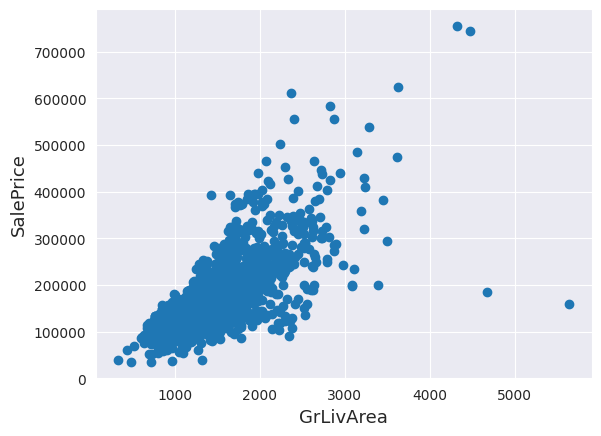

In [ ]:
fig, ax = plt.subplots()
ax.scatter(x=train['GrLivArea'], y=train['SalePrice'])
plt.ylabel('SalePrice', fontsize=13)
plt.xlabel('GrLivArea', fontsize=13)
plt.show()

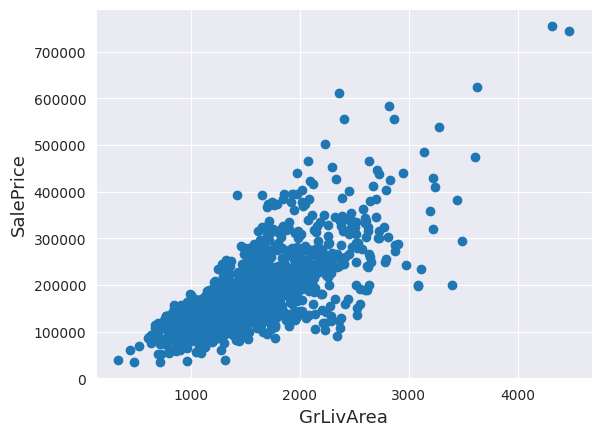

In [ ]:
train = train.drop(train[(train['GrLivArea']>4000) & (train['SalePrice']<300000)].index)

fig, ax = plt.subplots()
ax.scatter(x=train['GrLivArea'], y=train['SalePrice'])
plt.ylabel('SalePrice', fontsize=13)
plt.xlabel('GrLivArea', fontsize=13)
plt.show()


 mu = 180932.92 and sigma = 79467.79



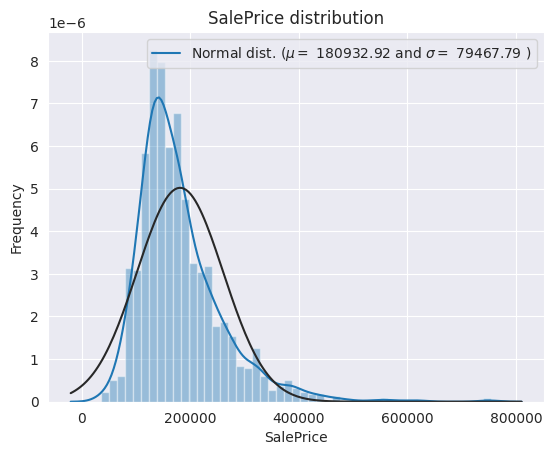

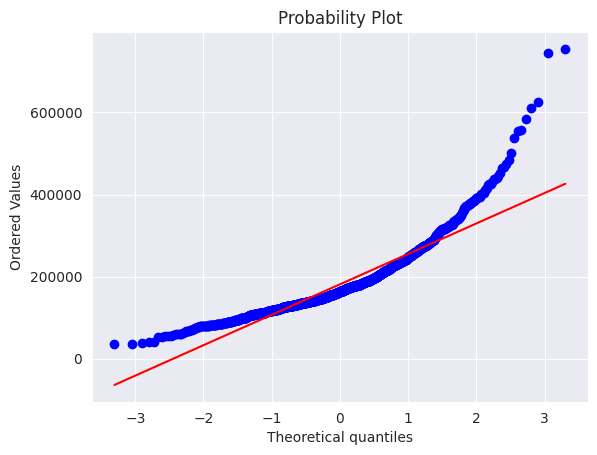

In [ ]:
sns.distplot(train['SalePrice'], fit=norm)

(mu, sigma) = norm.fit(train['SalePrice'])
print('\n mu = {:.2f} and sigma = {:.2f}\n'.format(mu, sigma))

# グラフに凡例（legend）を追加する処理
# $ ... $ の部分は Matplotlib が LaTeX風数式として解釈する
# ・\mu → ギリシャ文字 μ
# ・\sigma → ギリシャ文字 σ
# これで凡例が「Normal dist. (μ=..., σ=...)」という表示になる
# loc='best' :
# ・凡例の位置を自動調整
# ・'best' は「最もデータとかぶらない位置」に自動で配置
plt.legend(['Normal dist. ($\mu=$ {:.2f} and $\sigma=$ {:.2f} )'.format(mu, sigma)],
            loc='best')
plt.ylabel('Frequency')
plt.title('SalePrice distribution')

# SalePrice（住宅価格）のデータが正規分布に従っているかどうかをチェックするための「QQプロット」の描画
# res = stats.probplot(train['SalePrice'], plot=plt)
# ・stats.probplot は SciPy の関数で「確率プロット（QQプロット）」を描画する
# ・plot=plt → Matplotlib を使ってその場でグラフを描画するよう指定

# QQプロット（Quantile-Quantile plot）:
# ・データの分位点（quantile）と、理論的な分布（ここでは正規分布）の分位点を比べるプロット
# ・データが正規分布に従っていれば、点が対角線上に並ぶ
# ・正規性からズレていると、点が曲がったり端で外れたりする
# 点が直線から上に逸れる → 実際の値が理論分布より大きい（右裾が重い）
# 点が直線から下に逸れる → 実際の値が理論分布より小さい（左裾が重い）

# 右裾が長い分布（正の歪み）：
# ・真ん中付近は直線に沿う
# ・右端が直線より上に大きくはみ出す（大きな値が理論値よりも多い）
# ・左端は直線より下に行くこともある

# 左裾が長い分布（負の歪み）：
# ・右端が直線より下
# ・左端が直線より上
# ・逆向きのS字になる。
# ・グラフが「S字」や「放物線っぽく上に膨らむ」ように見える。

# 左裾が正規分布と比べて重かったり軽かったとしても、それ以上に右裾が重ければ、対数変換は有効である可能性が高い
fig = plt.figure()
res = stats.probplot(train['SalePrice'], plot=plt)
plt.show()

#f, ax = plt.subplots()
#res = stats.probplot(train['SalePrice'], plot=ax)


 mu = 12.02 and sigma = 0.40



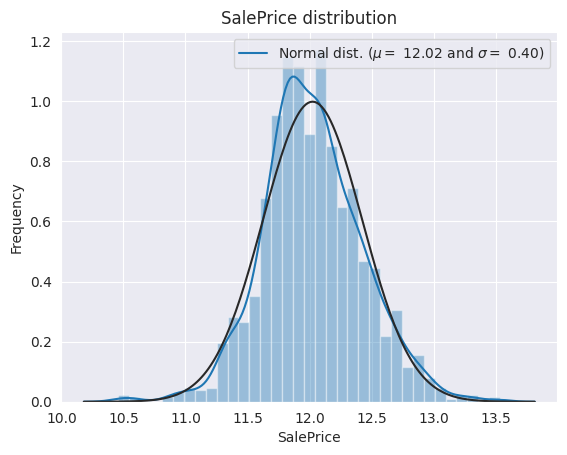

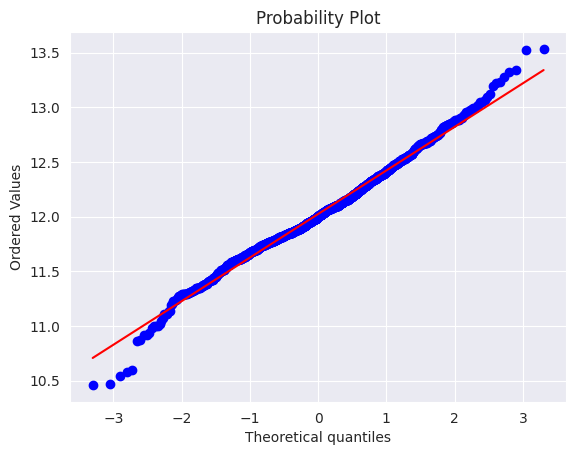

In [ ]:
train['SalePrice'] = np.log1p(train['SalePrice'])

sns.distplot(train['SalePrice'], fit=norm)
(mu, sigma) = norm.fit(train['SalePrice'])
print('\n mu = {:.2f} and sigma = {:.2f}\n'.format(mu, sigma))

plt.legend(['Normal dist. ($\mu=$ {:.2f} and $\sigma=$ {:.2f})'.format(mu, sigma)],
           loc = 'best')
plt.ylabel('Frequency')
plt.title('SalePrice distribution')

fig = plt.figure()
res = stats.probplot(train['SalePrice'], plot=plt)
plt.show()

In [ ]:
# 学習データ（train）とテストデータ（test）をまとめて「all_data」として1つの DataFrame に統合する前処理
# → all_data を作っておくことで、train/test まとめて同じ前処理を一度にかけられるようにしている

ntrain = train.shape[0]
ntest = test.shape[0]
y_train = train.SalePrice.values
all_data = pd.concat((train, test)).reset_index(drop=True)
all_data.drop(['SalePrice'], axis=1, inplace=True)
print('all_data size is : {}'.format(all_data.shape))

all_data size is : (2917, 79)


In [ ]:
all_data_na = (all_data.isnull().sum() / len(all_data)) * 100
# all_data_naはSeries
# Seriesでdropする行を選択するときはindexを渡す必要がある
all_data_na = all_data_na.drop(all_data_na[all_data_na == 0].index).sort_values(ascending=False)[:30]
missing_data = pd.DataFrame({'Missing Ratio' :all_data_na})
missing_data.head(20)

,Missing Ratio
PoolQC,99.691
MiscFeature,96.400
Alley,93.212
Fence,80.425
MasVnrType,60.542
FireplaceQu,48.680
LotFrontage,16.661
GarageQual,5.451
GarageYrBlt,5.451
GarageCond,5.451


In [ ]:
all_data_na

,0
PoolQC,99.691
MiscFeature,96.400
Alley,93.212
Fence,80.425
MasVnrType,60.542
FireplaceQu,48.680
LotFrontage,16.661
GarageQual,5.451
GarageYrBlt,5.451
GarageCond,5.451


Text(0.5, 1.0, 'Percent missing data by feature')

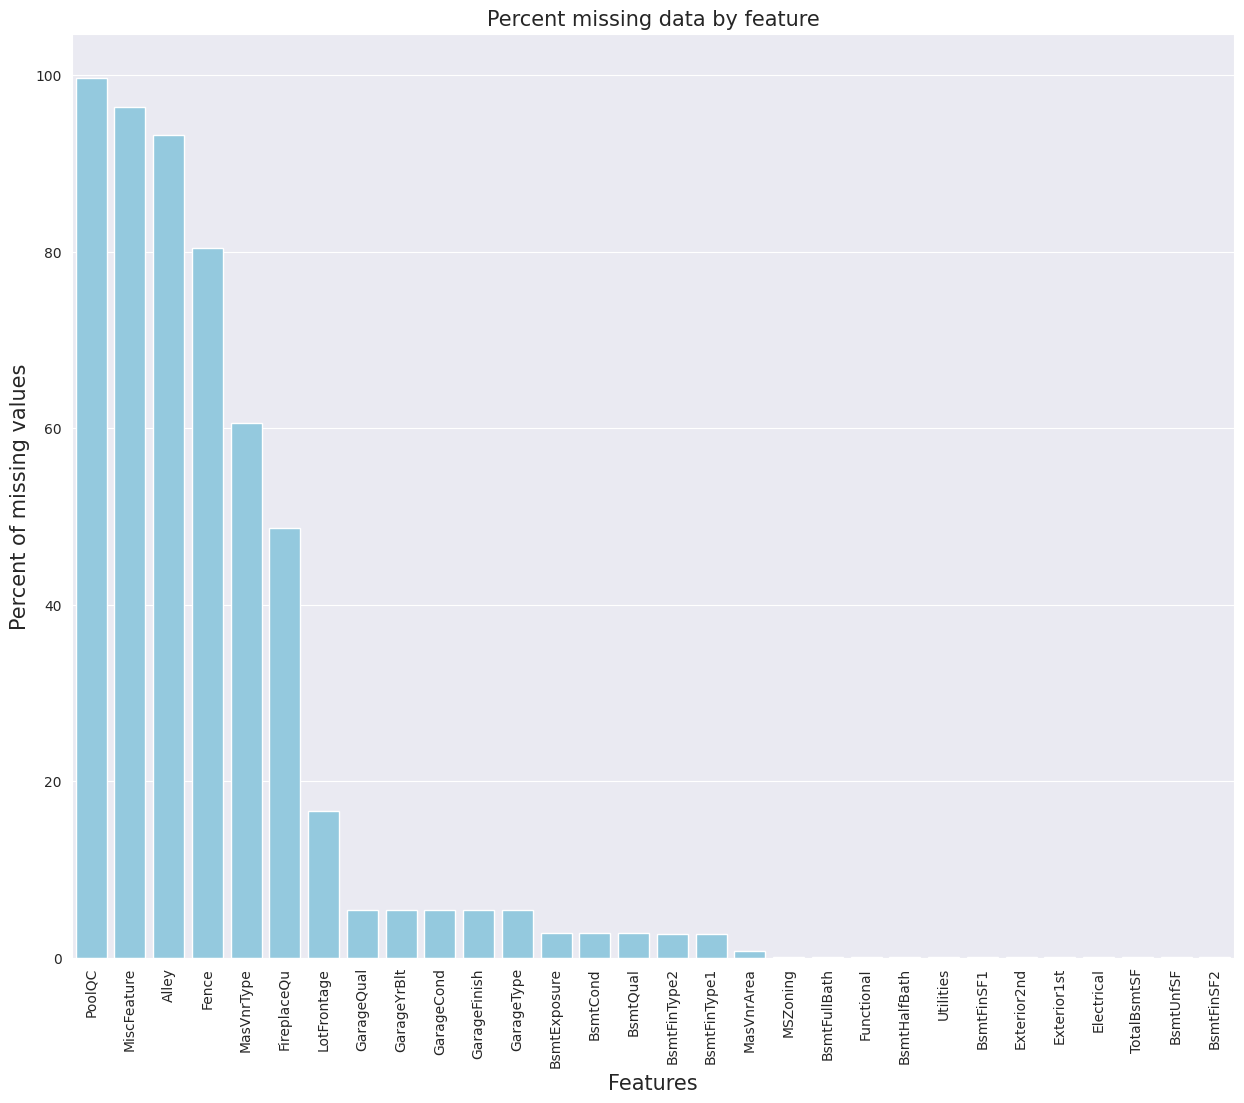

In [ ]:
f, ax = plt.subplots(figsize=(15,12))
plt.xticks(rotation=90)
sns.barplot(x=all_data_na.index, y=all_data_na, color='skyblue')
plt.xlabel('Features', fontsize=15)
plt.ylabel('Percent of missing values', fontsize=15)
plt.title('Percent missing data by feature', fontsize=15)

In [ ]:
all_data['GarageType'].unique()

# データ型を確認する
# dtype('O') : Object型（実務ではほとんどの場合、文字列データstr）
all_data['GarageType'].dtype
# DataFrame全体のデータ型の確認
all_data.dtypes

# カテゴリ変数のユニーク値ごとの件数集計
all_data['GarageType'].value_counts()
# 欠損値も含めたい場合
all_data['GarageType'].value_counts(dropna=False)

In [ ]:
# 欠損値処理(imputation)

# PoolQC は プールの品質
# データ説明書 (data description) によると、値が NA の場合 → 「プールが無い」ことを意味する
# 欠損率が 99%以上 → ほとんどの家にプールが無い。
# NaN のままにしておくと、モデルが「単なる欠測」と誤解してしまう。
# "None" として「プールなし」を明示すれば、モデルが正しく学習できる。
all_data['PoolQC'] = all_data['PoolQC'].fillna('None')
all_data["MiscFeature"] = all_data["MiscFeature"].fillna("None")
all_data["Alley"] = all_data["Alley"].fillna("None")
all_data["Fence"] = all_data["Fence"].fillna("None")
all_data["FireplaceQu"] = all_data["FireplaceQu"].fillna("None")

# df.groupby('列名')['対象列'].操作()
# groupby("列名")
# → 指定した列の値ごとにグループ分けする
# ["対象列"]
# → そのグループごとに対象列の値を取り出す
# .操作()
# → 例えば .mean(), .sum(), .median() などを計算

# groupby('Neighborhood')['LotFrontage'] → 各 Neighborhood ごとの LotFrontage Series の集合
# .transform(lambda x: ...) → その 各 Series に処理を適用（欠損を中央値で埋める）して、結果を 元の DataFrame の行の形に戻す
# .transform() は「グループごとに処理して、元の行数の形で返す」メソッド
all_data["LotFrontage"] = all_data.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median()))


# カテゴリは 'None'、数値は 0 に補完
for col in ('GarageType', 'GarageFinish', 'GarageQual', 'GarageCond'):
    all_data[col] = all_data[col].fillna('None')

for col in ('GarageYrBlt', 'GarageArea', 'GarageCars'):
    all_data[col] = all_data[col].fillna(0)

for col in ('BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF','TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath'):
    all_data[col] = all_data[col].fillna(0)

for col in ('BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2'):
    all_data[col] = all_data[col].fillna('None')

all_data["MasVnrType"] = all_data["MasVnrType"].fillna("None")
all_data["MasVnrArea"] = all_data["MasVnrArea"].fillna(0)

# MSZoning = 「一般的なゾーニング分類（用途地域）」を表すカテゴリ列
# 例：RL（住宅地：Residential Low Density）、RM（中密度住宅地）、C (Commercial) など
# データを見ると、RL が圧倒的に多い（最も一般的）
# 欠損値が少数であれば、最も多いカテゴリで補完するのが自然
# all_data['MSZoning'].mode()
# 最頻値（最もよく出る値）を返す。
# mode() は Series を返すので、[0] で1つ目を取り出す。
# このデータでは "RL"

print(all_data['MSZoning'].dtype)
print(all_data['MSZoning'].isnull().sum())
print()
print(all_data['MSZoning'].value_counts(dropna=False))

print('-------------------------------')

all_data['MSZoning'] = all_data['MSZoning'].fillna(all_data['MSZoning'].mode()[0])

# Utilities 列を削除している処理
# Utilities = 公共設備（水道・ガス・電気など）の有無を表すカテゴリ列。
# データを見ると：
# ・ほとんどの家は "AllPub"（全部揃っている）
# ・例外的に 1件だけ "NoSeWa"（下水道なし）
# ・さらに 2件が欠損値 (NA)
#　→つまり ほぼ全部同じ値
# ほとんどが "AllPub" でバリエーションがないので、予測に使える情報がほとんど無い
# 例外は学習データに1件だけなので、モデルが「Utilitiesによって価格が変わる」と学習することは期待できない
# こういう「ほぼ定数」の列は 特徴量として意味がない（情報量がゼロに近い）

print(all_data['Utilities'].dtype)
print(all_data['Utilities'].isnull().sum())
print()
print(all_data['Utilities'].value_counts(dropna=False))
print('-------------------------------')

all_data = all_data.drop(['Utilities'], axis=1)

# Functional = 住宅の機能性（住宅の機能がどれくらい通常どおりか）を表すカテゴリ変数
# データディクショナリ（Data Description）によると：
# ・"Typ" = Typical（標準的で問題なし）
# ・NA の場合は「特に問題なし（＝標準的）」を意味する
# .fillna("Typ") → 欠損値（NaN）を "Typ" に置き換える。
# →つまり、欠損があればそれは「標準的（Typ）」とみなして補完
print(all_data['Functional'].dtype)
print(all_data['Functional'].isnull().sum())
print()
print(all_data['Functional'].value_counts(dropna=False))

all_data["Functional"] = all_data["Functional"].fillna("Typ")

# Electrical = 家の電気システムのタイプを表すカテゴリ変数。
# データを見ると、ほとんどの家は "SBrkr"（Standard Circuit Breaker = 標準的なブレーカー）。
# 欠損は 1件だけ
print(all_data['Electrical'].dtype)
print(all_data['Electrical'].isnull().sum())
print()
print(all_data['Electrical'].value_counts(dropna=False))

all_data['Electrical'] = all_data['Electrical'].fillna(all_data['Electrical'].mode()[0])

# KitchenQual = キッチンの品質を表すカテゴリ変数
# 値の例: "Ex" (Excellent), "Gd" (Good), "TA" (Typical/Average), "Fa" (Fair) など。
# 欠損値は 1件だけ。
# データを見ると、最も多いカテゴリは "TA"（標準的なキッチン）
print(all_data['KitchenQual'].dtype)
print(all_data['KitchenQual'].isnull().sum())
print()
print(all_data['KitchenQual'].value_counts(dropna=False))

all_data['KitchenQual'] = all_data['KitchenQual'].fillna(all_data['KitchenQual'].mode()[0])

# Exterior1st = 建物の外壁材（1つ目）
# Exterior2nd = 建物の外壁材（2つ目、オプション）
# 値の例: VinylSd（ビニールサイディング）、MetalSd（金属）、Wd Sdng（木材）など。
# →欠損はどちらも 1件だけ
all_data['Exterior1st'] = all_data['Exterior1st'].fillna(all_data['Exterior1st'].mode()[0])
all_data['Exterior2nd'] = all_data['Exterior2nd'].fillna(all_data['Exterior2nd'].mode()[0])

# SaleType = 住宅の販売契約の種類
# "WD" = Warranty Deed - Conventional（通常の売買契約）
# "New" = 新築販売
# "COD" = Cash on Delivery（現金引換え）
# などいくつかの契約タイプがある。
# →データを見ると、大多数は "WD"。
# →欠損はごく少数（1件程度）
all_data['SaleType'] = all_data['SaleType'].fillna(all_data['SaleType'].mode()[0])

# MSSubClass = 建物のクラス（主に建物の種類やスタイルを表すコード）
# 20 = 1階建て（普通の住宅）
# 30 = 1階建て（デュプレックス）
# 60 = 2階建て（一般的な新しい住宅）
# →など、数値だけど「カテゴリー的な意味」を持つ変数
# →データ説明書では「NA = 建物クラスなし」を意味するとされる
# 欠損を "None" というラベルで置き換える
# →これにより「欠損」ではなく「クラスなし」という意味のカテゴリとしてモデルに認識させられる
all_data['MSSubClass'] = all_data['MSSubClass'].fillna("None")

In [ ]:
# 欠損値補完を一通りやったあとに、まだ欠損が残っていないかを確認する
all_data_na = (all_data.isnull().sum() / len(all_data)) * 100
all_data_na = all_data_na.drop(all_data_na[all_data_na == 0].index).sort_values(ascending=False)
missing_data = pd.DataFrame({'Missing Ratio' :all_data_na})
missing_data.head()

,Missing Ratio


In [ ]:
# 「数値っぽく見えるけど、本当はカテゴリー的に扱うべき特徴量」を文字列型に変換している処理
#MSSubClass=The building class
all_data['MSSubClass'] = all_data['MSSubClass'].apply(str)


#Changing OverallCond into a categorical variable
all_data['OverallCond'] = all_data['OverallCond'].astype(str)


#Year and month sold are transformed into categorical features.
all_data['YrSold'] = all_data['YrSold'].astype(str)
all_data['MoSold'] = all_data['MoSold'].astype(str)

# .astype(str)
#・pandas の型変換メソッド
#・Series 全体のデータ型を str に変換する
#・pandas 内部で効率的に処理されるので 速い & メモリ効率が良い

#.apply(str)
#・各要素に Python の str() 関数を適用する処理
#・つまり for ループで str(x) を全要素にかけているイメージ
#・より汎用的（例えば独自関数や複雑な変換ロジックも書ける）だが、astype より遅い

In [ ]:
from sklearn.preprocessing import LabelEncoder
cols = ('FireplaceQu', 'BsmtQual', 'BsmtCond', 'GarageQual', 'GarageCond',
        'ExterQual', 'ExterCond','HeatingQC', 'PoolQC', 'KitchenQual', 'BsmtFinType1',
        'BsmtFinType2', 'Functional', 'Fence', 'BsmtExposure', 'GarageFinish', 'LandSlope',
        'LotShape', 'PavedDrive', 'Street', 'Alley', 'CentralAir', 'MSSubClass', 'OverallCond',
        'YrSold', 'MoSold')

# all_data[c].values は pandas の Series（列データ）を NumPy の配列（ndarray）として取り出したもの
# scikit-learn の LabelEncoder は pandas の Series でも動きますが、元々は NumPy 配列を入力として設計されている
# list(...) → さらに Python のリストに変換（必須ではないけど安全策としてよく書かれる）

# all_data[c] = lbl.transform(list(all_data[c].values))
# 列 c のカテゴリデータを数値に変換
# ・変換後の数値で 元の列を置き換え
# ・これで機械学習モデルにそのまま入力できるようになる
for c in cols:
  lbl = LabelEncoder()
  lbl.fit(list(all_data[c].values))
  all_data[c] = lbl.transform(list(all_data[c].values))

print('Shape all_data: {}'.format(all_data.shape))


# LabelEncoder は 整数を割り当てるだけなので、「大小の順序がある」とモデルに解釈される可能性がある
# 線形回帰のように数値の大小をそのまま使うモデルでは注意が必要で、One-Hotエンコーディングの方が適切な場合も多い
# 決定木系（XGBoost, LightGBMなど）は整数ラベルをカテゴリとして扱えるので、このままでも問題ないことが多い

# One-Hot Encoding
#各カテゴリを 0/1 のダミー変数に展開する
#例：["Red","Blue","Green"] → [1,0,0], [0,1,0], [0,0,1]
#メリット：大小関係を持たないので線形モデルでも安心
#デメリット：カテゴリが多いと次元が爆発する（高次元・疎行列になる）

# Label Encoding
#各カテゴリを整数（0,1,2,…）に変換する
#例：["Red","Blue","Green"] → [2,0,1]（辞書順などで割り当て）
#メリット：列が1本のままで済む → メモリ効率が良い
#デメリット：整数に意味のない「順序」がついてしまう → 線形モデルや距離ベースのモデルでは誤解を招く

Shape all_data: (2917, 78)


In [ ]:
# 新しい特徴量（特徴量エンジニアリング） を作っている部分
# 家の価格に影響する要因の一つは「広さ（面積）」
# データには以下のように部屋ごとの面積がバラバラに入っています：
# ・TotalBsmtSF = 地下の総面積
# ・1stFlrSF = 1階の面積
# ・2ndFlrSF = 2階の面積
# →それぞれ単体で使うより、合計した総床面積 (Total Square Footage, TotalSF) を作った方が価格との関係をシンプルに捉えられることがある

# ・総床面積 = 家の全体的な広さ を表す指標を新たに作れる
# ・モデルに「広い家ほど価格が高い」という関係を学習させやすくなる
# ・単一の特徴量として扱えるので、線形回帰などで「広さと価格」の相関が強く出る

# Adding total sqfootage feature
all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']

In [ ]:
# 数値特徴量の分布がどれくらい歪んでいるか（skewness, 歪度）を調べる処理

numeric_feats = all_data.dtypes[all_data.dtypes != "object"].index

# pandas の DataFrame.apply() は、基本的に「列ごと」または「行ごと」に関数を適用
# デフォルトは axis=0（列方向）
skewed_feats = all_data[numeric_feats].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
print("\nSkew in numerical features: \n")
skewness = pd.DataFrame({'Skew' :skewed_feats})
skewness.head(10)


Skew in numerical features: 



,Skew
MiscVal,21.940
PoolArea,17.689
LotArea,13.109
LowQualFinSF,12.085
3SsnPorch,11.372
LandSlope,4.973
KitchenAbvGr,4.301
BsmtFinSF2,4.145
EnclosedPorch,4.002
ScreenPorch,3.945


In [ ]:
# 歪み（skewness）が大きい数値特徴量に Box–Cox 変換をかけて正規に近づける処理

# Box-Cox変換
# データの分布を“できるだけ正規分布に近づけるための非線形変換”

# 対数変換（log transform）も Box–Cox変換も「歪んだ分布を正規分布に近づける」ための変換手法
# → できることと柔軟さに違いがある
# どちらも 右に歪んだ分布（long right tail）を「縮める」 ためによく使われる
# <柔軟性>
# 対数変換
# ・固定された変換（λ=0のBox–Coxに相当）
# ・強めに歪みを縮める
# ・単純で計算も軽い
# Box–Cox変換
# ・λ（ラムダ）というパラメータで形を調整可能
# ・λ=1 → ほぼ元のまま
# ・λ=0 → log変換
# ・λを推定（最尤推定など）して「最も正規性が高くなる形」に合わせられる

# 使い分けの目安
# ・シンプルに済ませたいとき / 欠損や0が多いとき
# → np.log1p(x) で十分
# ・統計モデルの厳密さを重視 / 本当に正規性を追いたいとき
# → Box–Cox変換で λ を推定して適用
# ・実務やKaggleコンペ
# → 多くの場合、まず log変換（np.log1p） で十分効果あり
# → 精度を突き詰めたい場合は Box–Cox

# 対数変換 → 基本は「右に裾が長い分布」に使う（右歪み専用）
# Box–Cox変換 → λ を調整できるので、右歪みも左歪みも対応できる（ただし x>0 限定）
# ・λ が小さい（0に近い）
#  → 対数変換に近づき、大きな値を圧縮 → 右裾の歪み（正の歪み）を軽減しやすい
# ・λ が大きい（>1）
#  → 大きい値を広げる → 左裾の歪み（負の歪み）を軽減しやすい

# <実務でよく使う範囲>
# 0 ≤ λ ≤ 1 が最もよく使われる
# ・λ=0（log変換）
# ・λ=0.5（平方根変換）
# ・λ=1（変換なし）

skewness = skewness[abs(skewness) > 0.75]
print('There are {} skewed numerical features to Box-Cox transform'.format(skewness.shape[0]))

from scipy.special import boxcox1p
skewed_features = skewness.index
lam = 0.15
for feat in skewed_features:
  #all_data[feat] += 1
  all_data[feat] = boxcox1p(all_data[feat], lam)

#all_data[skewed_features] = np.log1p(all_data[skewed_features])

There are 59 skewed numerical features to Box-Cox transform


In [ ]:
# カテゴリ変数をダミー変数（One-Hotエンコーディング）に変換する処理

# pd.get_dummies(all_data) は カテゴリ変数（object 型や category 型）だけを One-Hot エンコーディング
# 数値データ（int, float）はそのまま
## LabelEncodderで変換した特徴量はintの数値のままになっている

all_data = pd.get_dummies(all_data)
print(all_data.shape)

(2917, 220)


In [ ]:
train = all_data[:ntrain]
test = all_data[ntrain:]

In [ ]:
# Modeling

In [ ]:
from sklearn.linear_model import ElasticNet, Lasso, BayesianRidge, LassoLarsIC
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.kernel_ridge import KernelRidge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.base import BaseEstimator, TransformerMixin, RegressorMixin, clone
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error
import xgboost as xgb
import lightgbm as lgb

In [ ]:
# 交差検証 (cross-validation) を使ってモデルの精度を評価する関数

n_folds = 5

# cross_val_score
# scikit-learn の関数で、交差検証 (cross-validation) を実行してスコアを返す
# ・model → 学習させたいモデル（LinearRegression, Lasso, Ridge, etc.）
# ・X → 説明変数（ここでは train.values = DataFrame を numpy array にしたもの）
# ・y → 目的変数（ここでは y_train = SalePrice）
# ・scoring → 評価指標（ここでは "neg_mean_squared_error"）
# ・cv → 分割方法（ここでは KFold オブジェクト kf）
# → これで「交差検証を行ったときのスコア一覧（foldごとの値）」が配列で返る

# scoring='mean_squared_error' は存在しないので使えない
# sklearn は「スコアは大きいほど良い」という設計ルールのため、MSE は 負で返す仕様
# だから "neg_mean_squared_error" を使って - を付け直すのが定番
# v0.22以降は "neg_root_mean_squared_error" で RMSE も直接OK
#Validation function
n_folds = 5


# この関数は交差検証でRMSEを出力する関数
# 目的変数を log 変換しているからrmsleとして定義している
# 返り値は交差検証で得られた各foldの RMSE を並べた NumPy 配列
def rmsle_cv(model):
    # 間違いの可能性あり：.get_n_splits(train.values)はKFoldの分割数のみを返すのでkf=5と同じになってしまう（シャッフルのしかたやランダムシードは無視されてしまう）
    #kf = KFold(n_folds, shuffle=True, random_state=42).get_n_splits(train.values)
    kf = KFold(n_folds, shuffle=True, random_state=42)
    rmse= np.sqrt(-cross_val_score(model, train.values, y_train, scoring="neg_mean_squared_error", cv = kf))
    return(rmse)

In [ ]:
# make_pipeline()
# データ前処理 → 学習モデル をまとめて一つの「処理の流れ（パイプライン）」として管理するための仕組み
# パイプラインは、「データの前処理を含めて一体化したモデル」

# <パイプラインなしの場合>
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)  # 前処理
# model = LinearRegression()
# model.fit(X_scaled, y)              # 学習

# <パイプラインありの場合>
# pipeline = make_pipeline(StandardScaler(), LinearRegression())
# pipeline.fit(X, y)        # 内部でStandardScaler.fit_transform → LinearRegression.fit が実行される
# y_pred = pipeline.predict(X_new)  # 内部でStandardScaler.transform → LinearRegression.predict が実行される

# ------------------------------------------------------------------------------------------------------------------

# RobustScaler:
# 外れ値に強い（ロバストな）標準化 を行うためのツール

# StandardScaler（標準化）
# x' = (x - 平均) / 標準偏差
# ・各特徴量を平均0・分散1にする
# ・正規分布に近いデータでは最も自然な標準化
# <メリット>
# ・線形回帰、ロジスティック回帰、SVM、PCA など「正規分布を仮定する/スケールに敏感な」アルゴリズムで有効
# ・係数の解釈がしやすい
# <デメリット>
# ・外れ値に弱い（1個大きな値があると平均・標準偏差が大きく歪む）
# ・0〜1 の範囲になるとは限らない
# <使う場面>
# ・データが正規分布っぽいとき
# ・線形モデルやPCAを使うとき

# MinMaxScaler（正規化）
# x' = (x - 最小値) / (最大値 - 最小値)
# ・0〜1にスケーリング
# ・各特徴量の相対的な大きさを保つ
# ・外れ値があると範囲が引き延ばされる
# <メリット>
# ・ニューラルネットや k-NN、SVM（RBFカーネル）など「距離」や「勾配」に敏感なアルゴリズムと相性が良い
# ・学習が速くなる
# <デメリット>
# ・外れ値に弱い(外れ値があると範囲が引き延ばされる)
# <使う場面>
# ・外れ値が少ない場合
# ・データを「0〜1」に揃えたい場合（ニューラルネットでは定番）

# RobustScaler（ロバストスケーリング）
# x' = (x - 中央値) / 四分位範囲(IQR)
# ・IQR（Interquartile Range）= 第3四分位数(Q3) − 第1四分位数(Q1)
# ・中央値・IQR を使うので外れ値の影響を受けにくい
# <メリット>
# ・外れ値が多いデータでも安定してスケーリングできる
# <デメリット>
# ・データが「正規分布に近い & 外れ値が少ない」場合、StandardScaler の方が適切
# ・データが [0, 1] に収まる保証はない
# ・RobustScaler は外れ値に強いけれど、外れ値が少ないときは他より精度が劣ることもある
# <使う場面>
# ・外れ値が多い場合
# ・モデルが線形回帰やLassoのように外れ値に敏感な場合

# ------------------------------------------------------------------------------------------------------------------

# Lasso
# Lassoは外れ値に弱い
# ロバストスケーリングを含めたモデルを作る
lasso = make_pipeline(
    RobustScaler(),
    Lasso(alpha=0.0005, random_state=1)
)

# Elastic Net Regression
# l1_ratio : L1とL2のどちらをどれくらい効かせるかを決めるハイパーパラメータ
ENet = make_pipeline(
    RobustScaler(),
    ElasticNet(alpha=0.0005, l1_ratio=.9, random_state=3)
)

# カーネルリッジ回帰
# カーネルリッジ回帰は、リッジで基本的な線形関係を捉えつつ、カーネルで指定したような関係も捉えるようなモデル
# ・非線形な関係を捉えたい（直線じゃ足りない）
# ・過学習せず安定させたい
# →リッジ正則化でコントロール）(カーネル法を使うとモデルが柔軟になりすぎて過学習しやすいが、
# 　KRRは リッジ回帰の正則化 (α) を組み合わせているので、複雑すぎない曲線に調整可能
# ・SVMよりシンプルに非線形回帰をやりたい

# 「どんなカーネルを選ぶか」＝「どんな形の非線形関係を捉えたいか」

# 線形カーネル (kernel="linear")
# <特徴>
# ・普通の線形回帰や線形SVMと同じ
# ・計算コストが小さい
# <使う場面>
# ・データが「ほぼ線形」で十分説明できるとき
# ・特徴量が多くて非線形化が不要な場合（テキストのBag-of-Wordsなど）

# 多項式カーネル (kernel="poly")
# <特徴>
# ・データ間の関係を多項式で捉える
# ・degree パラメータで曲線の複雑さを調整可能
# <使う場面>
# ・「2次曲線っぽい関係」や「3次曲線っぽい関係」がありそうなとき
# ・住宅価格のように「増加するけど途中から鈍化」といった非線形性を捉えたいとき

# RBFカーネル（ガウスカーネル, kernel="rbf")
# <特徴>
# ・無限次元に写像する
# ・非線形性を非常に柔軟に表現できる
# ・γ（ガンマ）パラメータで「どれくらい局所的に見るか」を調整
# <使う場面>
# ・データが複雑で、線形や多項式では捉えきれないとき
# ・一番よく使われるデフォルトカーネル

# シグモイドカーネル (kernel="sigmoid")
# <特徴>
# ・ニューラルネットの活性化関数（tanh）に相当
# ・実務ではあまり使われない（性能が不安定なことが多い）
# <使う場面>
# ・ニューラルネット的な挙動を試したいとき

# ------------------------------------------------------------------------------------------------------------------

# ・Lasso：特徴量が多い → 要らないものを削る（= 変数選択）
# ・Ridge：特徴量を削りたくない → 全体を縮めて安定化
# ・Kernel Ridge：Ridge の安定性 + カーネルで非線形対応

# ------------------------------------------------------------------------------------------------------------------

KRR = KernelRidge(alpha=0.6,    # 正則化の強さ
                  kernel='polynomial',   # カーネルの種類（多項式カーネル）
                  degree=2,    # 多項式の次数（2次多項式）→ degree=2 は 二次多項式を意味し、データの関係を「曲線（放物線的な形）」で捉える
                  coef0=2.5   # 多項式カーネルのオフセット → coef0 を大きくすると「線形部分」が強調され、小さいと「高次項（曲線部分）」が強調される
                  )


# ------------------------------------------------------------------------------------------------------------------


# 勾配ブースティング回帰
# <手順>
# ・最初の予測はyの平均値（MSEの場合）
# ・残差（正解-予測）を次の木のターゲットにする
# ・各木の分割基準は「残差（あるいは損失）のばらつきを最も減らす分割」
# ・葉に入るのは「そのノードに分類されたサンプルの残差の平均」
# ・学習率をかけて予測に少しずつ加える
# ・繰り返すことで残差が徐々に小さくなる
# <デメリット>
# ・複数の「決定木」を順番に作り、前の誤差（残差/勾配）を直す木を追加していく
# ・強力だが、木の分割候補を「すべて調べる」ので計算が重い
# ・サンプル数や特徴量が多いと遅い
# 　→ これを効率化・改良したのが XGBoost と LightGBM

# XGBoost
# GBDT を改良した実装で、爆発的に有名になったライブラリ
# 高精度＆比較的速い
# <特徴>
# ・正則化（L1+L2）:
# 　→過学習を防ぐ工夫が入っている（Lasso + Ridge のような効果）
# ・分割探索の効率化
# 　→全ての候補を試す代わりに、ヒストグラム近似で高速化
# ・並列処理に対応
# 　→CPU の複数コアを使って学習できる
# ・柔軟なオプション
# 　→損失関数・カスタム目的関数・評価指標が豊富

# LightGBM
# XGBoost よりさらに速く・軽くするために開発された GBDT ライブラリ
# <特徴>
# ・Leaf-wise の木成長
# ・高速学習（Histogramベース）
# ・大規模データに強い

# GradientBoostingRegressor、XGBoost、LightGBMの使い分け

# GradientBoostingRegressor
# <特徴>
# ・実装がシンプルで、scikit-learn との統合がしやすい
# ・デフォルトで小規模データに十分対応できる
# <欠点>
# ・学習速度が遅い（分割探索の工夫が少ない）
# ・並列化や大規模データには不向き
# <使う場面>
# ・学習サンプルが小規模（数千〜数万件程度）
# ・scikit-learn の Pipeline と組み合わせたいとき

# XGBoost
# <特徴>
# ・勾配ブースティングを効率的に実装
# ・L1・L2正則化があり過学習に強い
# ・CPU並列化や分割の効率化で GradientBoostingより数倍速い
# <欠点>
# ・メモリ消費はそこそこ多い
# ・LightGBMほどの高速性はない
# <使う場面>
# ・中規模データ（数万〜数十万件程度）
# ・安定した精度を重視したいとき
# ・Kaggleや実務で「とりあえず強いモデルを使いたい」ときの定番

# LightGBM
# <特徴>
# ・Microsoft製の GBDT 実装
# ・Leaf-wise（葉ごと）に木を成長 → 精度が上がりやすい
# ・ヒストグラム近似でメモリ効率も高く、XGBoostよりさらに高速・省メモリ
# ・カテゴリ変数をそのまま扱える機能あり（One-Hot不要）
# <欠点>
# ・Leaf-wise は過学習しやすい → パラメータ調整が難しいことも
# <使う場面>
# ・大規模データ（数十万〜数百万件以上）
# ・学習・予測速度が重要なとき
# ・Kaggleで高速に試行錯誤したいとき

# データが小規模（数千〜数万件） → GradientBoostingRegressor でも十分
# 中規模（数万〜数十万件）で高精度が欲しい → XGBoost
# 大規模（数十万〜数百万件以上）で高速・省メモリが重要 → LightGBM
# とりあえずKaggleで勝ちたい → LightGBM か XGBoost の両方試すのが定番

GBoost = GradientBoostingRegressor(n_estimators=3000,      # 木の本数（弱学習器の数）
                                   learning_rate=0.05,     # 学習率（1本の木の寄与度）
                                   max_depth=4,            # 各木の深さ
                                   max_features='sqrt',    # 分割に使う特徴量の数
                                   min_samples_leaf=15,    # 葉ノードに必要な最小サンプル数
                                   min_samples_split=10,   # 内部分割を行うのに必要な最小サンプル数
                                   loss='huber',           # 損失関数（外れ値に強いHuber損失）
                                   random_state =5         # 乱数シード（再現性）
                                   )

# n_estimators=3000
# ・作る木の数（ブースティングのステップ数）
# ・多ければ表現力は上がるが、計算も遅くなる＆過学習リスク
# ・小さめの learning_rate と組み合わせるのが定石
# 　・例：learning_rate=0.05, n_estimators=3000 / learning_rate=0.1, n_estimators=1000

# learning_rate=0.05
# ・各木が予測に与える影響をどのくらいにするか。
# ・小さくすると「一歩一歩慎重に」学習（過学習防止）、ただし木の数が必要
# ・大きいと「一気に修正」するが、暴走（過学習）しやすい

# max_depth=4
# ・各木の深さ
# ・深いと複雑な関係を捉えられるが過学習しやすい
# ・ブースティングでは浅い木（3〜5程度）がよく使われる

# max_features='sqrt'
# ・各分割で使う特徴量の数
# ・'sqrt' = 特徴量数の平方根
# ・特徴量をランダムに選んで分割に使うことで、過学習を防ぎ、計算も速くなる

# min_samples_leaf=15
# ・葉ノード（末端）に必要なサンプルの最小数
# ・小さい → 細かく分ける（過学習しやすい）
# ・大きい → 大まかに分ける（安定）

# min_samples_split=10
# ・ノードを分割するのに必要な最小サンプル数
# ・サンプル数がこれ未満なら分割しない
# ・小さい値 → 細かい分割を許す（過学習寄り）

# loss='huber'
# ・損失関数の指定
# ・「勾配ブースティング木の損失関数」とは、“どんなズレを重視して直していくか”を決めるもの
# ・デフォルトは "squared_error"（MSE）
# ・"huber" は外れ値に強い損失関数

model_xgb = xgb.XGBRegressor(
    colsample_bytree=0.4603,   # 各木で使う特徴量の割合
    gamma=0.0468,              # 木を分割するときの最小損失減少
    learning_rate=0.05,        # 学習率（η）
    max_depth=3,               # 木の深さ
    min_child_weight=1.7817,   # 子ノードに必要な最小の重み（サンプル数のしきい値に相当）
    n_estimators=2200,         # 木の本数
    reg_alpha=0.4640,          # L1 正則化（Lasso的な効果）
    reg_lambda=0.8571,         # L2 正則化（Ridge的な効果）
    subsample=0.5213,          # 各木を作るときに使うサンプルの割合
    silent=1,                  # 出力ログを抑制（古いバージョンで有効）
    random_state=7,            # 乱数シード
    nthread=-1                 # CPUスレッド数（-1は全コア使用）
)

# nthread=-1
# ・CPUの全スレッドを使って並列計算 → 学習を高速化

# subsample=0.5213
# ・各木を作るときにサンプルをランダムに 52% だけ使う
# ・ランダム性を導入して過学習を防ぐ

# colsample_bytree=0.4603
# ・各木を作るときに特徴量をランダムに 46% だけ使う
# ・これも過学習防止＆学習の多様性UP

#gamma=0.0468
# ・ノードを分割するのに必要な「最小の損失減少」
# ・大きいほど分割に厳しくなり → 木がシンプルになる

# min_child_weight=1.7817
# ・子ノードに割り当てる最小の「重み（サンプル数×重み）」
# ・大きいと分割が起こりにくく、シンプルな木になる

model_lgb = lgb.LGBMRegressor(
    objective='regression',     # 学習タスク（ここでは回帰）
    num_leaves=5,               # 木の葉の数（モデルの複雑さを決める）
    learning_rate=0.05,         # 学習率
    n_estimators=720,           # 木の数（弱学習器の数）
    max_bin=55,                 # 連続値をヒストグラムに分割する際のビン数
    bagging_fraction=0.8,       # データのサンプリング率（ランダム性導入で過学習防止）
    bagging_freq=5,             # バギングを行う頻度（5なら5イテレーションごとにサンプリング）
    feature_fraction=0.2319,    # 特徴量のサンプリング率
    feature_fraction_seed=9,    # 特徴量サンプリングの乱数シード
    bagging_seed=9,             # データサンプリングの乱数シード
    min_data_in_leaf=6,         # 葉ノードに入る最小データ数
    min_sum_hessian_in_leaf=11  # 葉に必要な最小のヘッセ行列の和（分割の信頼性の閾値）
)

# num_leaves=5
# ・1本の木にできる葉の最大数。
# ・値を増やすと複雑なモデルになり、精度は上がるが過学習リスクも上がる。
# ・小さいとシンプルで安定。

# min_data_in_leaf=6
# ・葉に入る最小サンプル数。過学習防止のための制御。

# min_sum_hessian_in_leaf=11
# ・各葉の「勾配の2乗和（Hessianの和）」の最小値。分割の信頼性を担保するための閾値。

# bagging_fraction=0.8
# ・各木を作るときに80%のサンプルをランダムに抽出して学習。

# bagging_freq=5
# ・5イテレーションごとにサンプリングを実施。

# feature_fraction=0.2319
# ・各木を作るときに特徴量の23%をランダムに使用。ランダムフォレストの「特徴量サンプリング」と同じ発想。

# max_bin=55
# ・LightGBMは連続値をビンに区切って学習する。ビン数が大きいと精度は上がるが計算が重い。

In [ ]:
# ハイパーパラメータ探索（Lasso）

# Grid search
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler

# make pipline
lasso = make_pipeline(
    RobustScaler(),
    Lasso(random_state=1)
)

# 探索するパラメータ候補
param_grid = {
    "lasso__alpha": [1e-4, 5e-4, 1e-3, 1e-2, 2e-1]
}

# grid search
grid_search = GridSearchCV(lasso, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(train.values, y_train)

print('Best params : ', grid_search.best_params_)
print('Best score (MSE) : ', -grid_search.best_score_)
print('================================================')

# Random Search
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_dict = {
    "lasso__alpha": np.logspace(-4, 0, 50) # # 10^-4 ～ 1 の範囲をランダムに

}

random_search = RandomizedSearchCV(
    lasso,
    param_distributions=param_dict,
    n_iter=20,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42

)

random_search.fit(train.values, y_train)
print('Best params : ', random_search.best_params_)
print('Best score (MSE)', -random_search.best_score_)
print('================================================')

# Optuna
import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):
  alpha = trial.suggest_float('alpha', 1e-5, 1, log=True)
  model = make_pipeline(
      RobustScaler(),
      Lasso(alpha=alpha, random_state=1)
  )
  score = cross_val_score(
      model,
      train.values,
      y_train,
      scoring='neg_mean_squared_error',
      cv=5
  )
  rmse = np.sqrt(-score.mean())
  return rmse

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

print('Best params : ', study.best_params)
print('Best score (RMSE) : ', study.best_value)
print('================================================')
# ==============================================================================

# ハイパーパラメータの探索(ElasticNet)

# grid search
ENet = make_pipeline(
    RobustScaler(),
    ElasticNet(random_state=3)
)

param_grid = {
    'elasticnet__alpha': [1e-4, 3e-4, 5e-4, 1e-3, 3e-3, 1e-2],
    'elasticnet__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

grid_search = GridSearchCV(ENet, param_grid, cv =5, scoring='neg_mean_squared_error')
grid_search.fit(train.values, y_train)

print('Best params : ', grid_search.best_params_)
print('Best score (MSE) : ', -grid_search.best_score_)

# random search

from scipy.stats import loguniform, uniform  # 分布サンプリング用

param_dict = {
    'elasticnet__alpha' : loguniform(1e-5, 1e-1),  # 10^-5 ~ 10^-1 を対数スケールで
    'elasticnet__l1_ratio' : uniform(0, 1)         # 0 ~ 1 の一様分布
}

random_search = RandomizedSearchCV(
    ENet,
    param_distributions=param_dict,
    n_iter=20,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

random_search.fit(train.values, y_train)
print('Best prams : ', random_search.best_params_)
print('Best score (MSE) : ', -random_search.best_score_)


# Optuna
def objective(trial):
  alpha = trial.suggest_float('alpha', 1e-5, 1, log=True)
  l1_ratio = trial.suggest_float('lr_ratio', 0.0, 1.0)

  model = make_pipeline(
      RobustScaler(),
      ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=3)
  )

  score = cross_val_score(
      model,
      train.values,
      y_train,
      scoring='neg_mean_squared_error',
      cv=5,
      n_jobs=-1
  )
  rmse = np.sqrt(-score.mean())
  return rmse

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

print('Best params : ', study.best_params)
print('Best score : ', study.best_value)
# ==============================================================================
# ハイパーパラメータの探索(KRR)

from scipy.stats import loguniform, uniform, randint

# grid search
KRR = make_pipeline(
    RobustScaler(),
    KernelRidge()
)

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import GridSearchCV, KFold
import numpy as np

X = train.values
y = y_train
cv = KFold(n_splits=5, shuffle=True, random_state=42)

KRR = make_pipeline(RobustScaler(), KernelRidge())

param_grid = [
    # linear
    {
        "kernelridge__kernel": ["linear"],
        "kernelridge__alpha": [1e-3, 1e-2, 1e-1, 1.0]
    },
    # rbf
    {
        "kernelridge__kernel": ["rbf"],
        "kernelridge__alpha": [1e-3, 1e-2, 1e-1, 1.0],
        "kernelridge__gamma":  [1e-4, 1e-3, 1e-2, 1e-1]
    },
    # polynomial
    {
        "kernelridge__kernel": ["polynomial"],
        "kernelridge__alpha":  [1e-3, 1e-2, 1e-1, 1.0],
        "kernelridge__degree": [2, 3, 4],
        "kernelridge__gamma":  [None, 1e-3, 1e-2, 1e-1],
        "kernelridge__coef0":  [0.0, 1.0, 2.5]
    }
]

grid_search = GridSearchCV(
    KRR,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=0
)
grid_search.fit(train.values, y_train)

print('Best params : ', grid_search.best_params_)
print('Best Score : ', -grid_search.best_score_)
print('================================================')

# random search

param_dist = [
    # linear
    {
        "kernelridge__kernel": ["linear"],
        "kernelridge__alpha": loguniform(1e-4, 1e1)  # 1e-4〜10
    },
    # rbf
    {
        "kernelridge__kernel": ["rbf"],
        "kernelridge__alpha": loguniform(1e-4, 1e1),
        "kernelridge__gamma": loguniform(1e-4, 1e0)  # 1e-4〜1
    },
    # polynomial
    {
        "kernelridge__kernel": ["polynomial"],
        "kernelridge__alpha": loguniform(1e-4, 1e1),
        "kernelridge__degree": randint(2, 6),        # {2,3,4,5}
        "kernelridge__gamma": loguniform(1e-4, 1e0), # 1e-4〜1
        "kernelridge__coef0": uniform(0.0, 3.0)      # 0〜3
    }
]

random_serach = RandomizedSearchCV(
    KRR,
    param_distributions=param_dist,
    scoring="neg_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=0
)

random_serach.fit(X, y)

print("RandomSearch best params:", random_serach.best_params_)
print("RandomSearch best RMSE:", np.sqrt(-random_serach.best_score_))

# Optuna

import optuna

def objective(trial):
    kernel = trial.suggest_categorical("kernel", ["linear", "rbf", "polynomial"])
    alpha  = trial.suggest_float("alpha", 1e-4, 1e1, log=True)

    params = {"kernel": kernel, "alpha": alpha}

    if kernel == "rbf":
        params["gamma"] = trial.suggest_float("gamma", 1e-4, 1e0, log=True)

    elif kernel == "polynomial":
        params["degree"] = trial.suggest_int("degree", 2, 5)
        params["gamma"]  = trial.suggest_float("gamma", 1e-4, 1e0, log=True)
        params["coef0"]  = trial.suggest_float("coef0", 0.0, 3.0)

    KRR = make_pipeline(
        RobustScaler(),
        KernelRidge(**params)
    )

    scores = cross_val_score(
        KRR,
        train.values,
        y_train,
        scoring="neg_mean_squared_error",
        cv=cv,
        n_jobs=-1
    )
    rmse = np.sqrt(-scores.mean())
    return rmse

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

print("Optuna best params:", study.best_params)
print("Optuna best RMSE:", study.best_value)
# ==============================================================================
# ハイパーパラメータの探索（GBoost）

# Grid search
GBoost = GradientBoostingRegressor(random_state=5)

param_grid = {
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators":  [800, 1500, 3000],
    "max_depth":     [2, 3, 4],
    "subsample":     [0.7, 1.0],
    "max_features":  ["sqrt", None],
    "min_samples_leaf":  [5, 10, 15],
    "min_samples_split": [5, 10, 20],
    "loss": ["huber"],
    "alpha": [0.85, 0.9, 0.95]
}

grid_search = GridSearchCV(
    GBoost,
    param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1
)

grid_search.fit(train.values, y_train)
print("Grid best params:", grid_search.best_params_)
print("Grid best RMSE:", np.sqrt(-grid_search.best_score_))
print('================================================')

# Random search

Gboost = GradientBoostingRegressor(random_state=5)

param_dist = {
    "learning_rate":   loguniform(1e-3, 3e-1),
    "n_estimators":    randint(500, 4000),
    "max_depth":       randint(2, 6),
    "subsample":       uniform(0.6, 0.4),   # 0.6〜1.0
    "max_features":    ["sqrt", None],
    "min_samples_leaf":  randint(3, 25),
    "min_samples_split": randint(4, 25),
    "loss":            ["huber"],
    "alpha":           uniform(0.8, 0.19)   # 0.8〜0.99
}

rs = RandomizedSearchCV(
    GBoost,
    param_distributions=param_dist,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
    random_state=42
)
rs.fit(train.values, y_train)
print("Random best params:", rs.best_params_)
print("Random best RMSE:", np.sqrt(-rs.best_score_))
print('================================================')

# Optuna

def objective(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 3e-1, log=True),
        "n_estimators":  trial.suggest_int("n_estimators", 600, 4000),
        "max_depth":     trial.suggest_int("max_depth", 2, 6),
        "subsample":     trial.suggest_float("subsample", 0.6, 1.0),
        "max_features":  trial.suggest_categorical("max_features", ["sqrt", None]),
        "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 3, 25),
        "min_samples_split": trial.suggest_int("min_samples_split", 4, 25),
        "loss":          trial.suggest_categorical("loss", ["huber"]),  # 必要に応じて拡げる
        "alpha":         trial.suggest_float("alpha", 0.80, 0.99),      # huber用
        "random_state":  5
    }

    Gboost = GradientBoostingRegressor(**params)
    scores = cross_val_score(
        GBoost,
        train.values,
        y_train,
        scoring="neg_mean_squared_error",
        cv=5,
        n_jobs=-1
    )
    return np.sqrt(-scores.mean())

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

print("Optuna best params:", study.best_params)
print("Optuna best RMSE:", study.best_value)
print('================================================')
# ==============================================================================
# ハイパーパラメータ探索（XGBoost）

#Grid search

model_xgb = xgb.XGBRegressor(
    objective="reg:squarederror",
    random_state=7,
    nthread=-1
)


param_grid = {
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [1000, 2000, 3000],
    "max_depth": [2, 3, 4],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.3, 0.6, 0.9],
    "gamma": [0, 0.05, 0.1]
}

gs = GridSearchCV(
    model_xgb,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)
gs.fit(train.values, y_train)

print("Best params:", gs.best_params_)
print("Best RMSE:", np.sqrt(-gs.best_score_))
print('================================================')

# Random search

param_dist = {
    "learning_rate": loguniform(1e-3, 0.3),   # 0.001〜0.3
    "n_estimators": randint(500, 4000),       # 500〜4000
    "max_depth": randint(2, 8),               # 2〜7
    "min_child_weight": uniform(1, 6),        # 1〜7
    "subsample": uniform(0.5, 0.5),           # 0.5〜1.0
    "colsample_bytree": uniform(0.3, 0.7),    # 0.3〜1.0
    "gamma": uniform(0, 0.2),                 # 0〜0.2
    "reg_alpha": loguniform(1e-3, 10),        # L1正則化
    "reg_lambda": loguniform(1e-3, 10)        # L2正則化
}

rs = RandomizedSearchCV(
    model_xgb,
    param_distributions=param_dist,
    n_iter=80,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    random_state=42,
    verbose=1
)
rs.fit(train.values, y_train)

print("Best params:", rs.best_params_)
print("Best RMSE:", np.sqrt(-rs.best_score_))
print('================================================')

# Optuna

def objective(trial):
    params = {
        "objective": "reg:squarederror",
        "random_state": 7,
        "nthread": -1,
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 500, 4000),
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "min_child_weight": trial.suggest_float("min_child_weight", 1, 7),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.3, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 0.2),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10, log=True)
    }

    model = xgb.XGBRegressor(**params)

    scores = cross_val_score(
        model,
        train.values,
        y_train,
        scoring="neg_mean_squared_error",
        cv=5,
        n_jobs=-1
    )
    return np.sqrt(-scores.mean())

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("Optuna best params:", study.best_params)
print("Optuna best RMSE:", study.best_value)
print('================================================')
# ==============================================================================
# ハイパーパラメータ探索（LightGBM）

# grid search
model_lgb = lgb.LGBMRegressor(
    objective="regression",
    random_state=9,              # 再現性確保
    n_jobs=-1                    # 並列化
)

param_grid = {
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "n_estimators":  [400, 720, 1200],
    "num_leaves":    [5, 15, 31, 63],
    "max_bin":       [31, 55, 127, 255],
    "feature_fraction": [0.2, 0.4, 0.6, 0.8],
    "bagging_fraction": [0.6, 0.8, 1.0],
    "bagging_freq":  [0, 5, 10],
    "min_data_in_leaf": [5, 10, 20, 40],
    "min_sum_hessian_in_leaf": [1e-3, 1e-2, 1e-1]
}

gs = GridSearchCV(
    model_lgb,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=1
)
gs.fit(train.values, y_train)
print("Grid best params:", gs.best_params_)
print("Grid best RMSE:", np.sqrt(-gs.best_score_))

# Random search

from scipy.stats import randint, uniform, loguniform

param_dist = {
    "learning_rate": loguniform(1e-3, 3e-1),     # 0.001〜0.3
    "n_estimators":  randint(400, 3000),
    "num_leaves":    randint(5, 128),
    "max_bin":       randint(31, 255),
    "feature_fraction": uniform(0.2, 0.8),       # 0.2〜1.0
    "bagging_fraction": uniform(0.5, 0.5),       # 0.5〜1.0
    "bagging_freq":  randint(0, 10),
    "min_data_in_leaf": randint(5, 60),
    "min_sum_hessian_in_leaf": loguniform(1e-3, 1.0)
}

rs = RandomizedSearchCV(
    model_lgb,
    param_distributions=param_dist,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)
rs.fit(train.values, y_train)
print("Random best params:", rs.best_params_)
print("Random best RMSE:", np.sqrt(-rs.best_score_))


model_lgb = lgb.LGBMRegressor(
    objective="regression",
    random_state=9,              # 再現性確保
    n_jobs=-1                    # 並列化
)

#Optuna

def objective(trial):
    params = {
        "objective": "regression",
        "random_state": 9,
        "n_jobs": -1,

        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 3e-1, log=True),
        "n_estimators":  trial.suggest_int("n_estimators", 400, 3000),
        "num_leaves":    trial.suggest_int("num_leaves", 5, 128),
        "max_bin":       trial.suggest_int("max_bin", 31, 255),

        "feature_fraction": trial.suggest_float("feature_fraction", 0.2, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.5, 1.0),
        "bagging_freq":     trial.suggest_int("bagging_freq", 0, 10),

        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 5, 60),
        "min_sum_hessian_in_leaf": trial.suggest_float("min_sum_hessian_in_leaf", 1e-3, 1.0, log=True),
    }

    model_lgb = lgb.LGBMRegressor(**params)

    scores = cross_val_score(
        model_lgb,
        train.values,
        y_train,
        scoring="neg_mean_squared_error",
        cv=5,
        n_jobs=-1
    )
    return np.sqrt(-scores.mean())

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=120, show_progress_bar=True)

print("Optuna best params:", study.best_params)
print("Optuna best RMSE:", study.best_value)

In [ ]:
# Base model

# LASSO Regression
lasso = make_pipeline(RobustScaler(), Lasso(alpha =0.0005, random_state=1))

# Elastic Net Regression
ENet = make_pipeline(RobustScaler(), ElasticNet(alpha=0.0005, l1_ratio=.9, random_state=3))

# Kernel Ridge Regression
KRR = KernelRidge(alpha=0.6, kernel='polynomial', degree=2, coef0=2.5)

# Gradient Boosting Regression
GBoost = GradientBoostingRegressor(n_estimators=3000, learning_rate=0.05,
                                   max_depth=4, max_features='sqrt',
                                   min_samples_leaf=15, min_samples_split=10,
                                   loss='huber', random_state =5)

# XGBoost
model_xgb = xgb.XGBRegressor(colsample_bytree=0.4603,
                             gamma=0.0468,
                             learning_rate=0.05,
                             max_depth=3,
                             min_child_weight=1.7817,
                             n_estimators=2200,
                             reg_alpha=0.4640,
                             reg_lambda=0.8571,
                             subsample=0.5213,
                             silent=1,
                             random_state =7,
                             nthread = -1)

# LightGBM
model_lgb = lgb.LGBMRegressor(objective='regression',
                              num_leaves=5,
                              learning_rate=0.05,
                              n_estimators=720,
                              max_bin = 55,
                              bagging_fraction = 0.8,
                              bagging_freq = 5,
                              feature_fraction = 0.2319,
                              feature_fraction_seed=9,
                              bagging_seed=9,
                              min_data_in_leaf =6,
                              min_sum_hessian_in_leaf = 11)

In [ ]:
score = rmsle_cv(lasso)
print("\nLasso score: {:.4f} ({:.4f})\n".format(score.mean(), score.std()))


Lasso score: 0.1115 (0.0074)



In [ ]:
score = rmsle_cv(ENet)
print("ElasticNet score: {:.4f} ({:.4f})\n".format(score.mean(), score.std()))

ElasticNet score: 0.1116 (0.0074)



In [ ]:
score = rmsle_cv(KRR)
print("Kernel Ridge score: {:.4f} ({:.4f})\n".format(score.mean(), score.std()))

Kernel Ridge score: 0.1153 (0.0075)



In [ ]:
score = rmsle_cv(GBoost)
print("Gradient Boosting score: {:.4f} ({:.4f})\n".format(score.mean(), score.std()))

Gradient Boosting score: 0.1167 (0.0083)



In [ ]:
score = rmsle_cv(model_xgb)
print("Xgboost score: {:.4f} ({:.4f})\n".format(score.mean(), score.std()))

Xgboost score: 0.1162 (0.0078)



In [ ]:
score = rmsle_cv(model_lgb)
print("LGBM score: {:.4f} ({:.4f})\n" .format(score.mean(), score.std()))

[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319

In [ ]:
df_models_loss = pd.DataFrame({
    'score(rmsle)' : [score_lasso.mean(), score_enet.mean(), score_krr.mean(), score_gboost.mean(), score_xgb.mean(), score_lgb.mean()],
    'std' : [score_lasso.std(), score_enet.std(), score_krr.std(), score_gboost.std(), score_xgb.std(), score_lgb.std()]
})
df_models_loss.index = ['Lasso', 'ElasticNet', 'Kernel Ridge', 'Gradient Boost', 'XGBoost', 'LightGBN']
df_models_loss.style.highlight_min(color='blue', axis=0)

In [ ]:
# スタッキング（アンサンブル学習） の一種である「単純平均（Averaging）」を scikit-learn のモデルとして実装
# ・アンサンブル学習 = 複数のモデルを組み合わせて予測を行う手法
# ・その中で最もシンプルなのが 「各モデルの予測を平均する」 方法
#  ・例：Lasso、Ridge、XGBoost、LightGBM の予測を取って平均 → より安定した予測

# アンサンブル学習もモデルをクラスとして定義するときに継承するクラス
# BaseEstimator
# ・最低限必須
# RegressorMixin
# ・回帰モデル用
# ・score() が R² で計算される
# ClassifierMixin
# ・分類モデル用
# ・score() が accuracy で計算される
# TransformerMixin
# ・前処理用（特徴量変換器など）
# ・fit_transform() を自動で提供

# アンサンブル学習用に自作クラスを作るときは
# ・回帰タスクなら BaseEstimator + RegressorMixin
# ・分類タスクなら BaseEstimator + ClassifierMixin
# ・前処理的に使いたければ TransformerMixin も足す

class AveragingModels(BaseEstimator, RegressorMixin, TransformerMixin):
  def __init__(self, models):
    self.models = models

  def fit(self, X, y):
    self.models_ = [clone(x) for x in self.models]

    # train cloned base models
    for model in self.models_:
      model.fit(X, y)

    return self

  def predict(self, X):
    predictions = np.column_stack([
        model.predict(X) for model in self.models_
    ])
    return np.mean(predictions, axis=1)

# (n_samples, n_models) をaxis=1でモデルごとの平均をとる → (n_samples,)

In [ ]:
average_models = AveragingModels(models = (ENet, GBoost, KRR, lasso))

score = rmsle_cv(average_models)
print(' Averaged base models score: {:.4f} ({:.4f})\n'.format(score.mean(), score.std()))

 Averaged base models score: 0.1087 (0.0077)



In [ ]:
df_models_loss.loc['Averaged base models'] = {'score(rmsle)':score.mean(), 'std':score.std()}
df_models_loss.style.highlight_min(color='blue', axis=0)

In [ ]:
# スタッキング

# シンプルなアンサンブル（複数のモデルの出力を重み付けなしで平均して最終予測とする）は簡単
# → 一方、「モデルごとの予測に重みをつけたり、もっと賢く組み合わせる」ことはできない

# スタッキング
# ・各モデルの予測を、そのまま「新しい特徴量」として扱う
# ・各モデルの予測を使って、新しいデータセットを作り、その上でさらに別のモデルを学習させる
# ・それらを入力にして、もう１つの「上位モデル（Meta-model）」を学習させる
# ・こうすることで「どのモデルの予測をどれくらい信じるか」をメタモデルが自動で学習できる

# <学習の流れ>
# ・データを分割する（例：5-fold cross validation）
# ・各foldで、ベースモデルを訓練 → 検証用foldで予測する
# 　→この「検証foldに対する予測」を out-of-fold predictions (OOF予測) と呼ぶ
# ・5回繰り返すと、すべてのサンプルに対して「ベースモデルのOOF予測値」が得られる
# 　→つまり「Lassoの予測」「Ridgeの予測」「XGBの予測」などが新しい特徴量になる
# ・その予測値（OOF予測値）を入力、元の正解yを出力として メタモデル（例：LassoやRidgeなど）を学習する

# <予測時の流れ>
# ・各ベースモデルでテストデータを予測する
# 　→「ベースモデルの予測値のセット」が得られる（これがメタ特徴量）
# ・そのメタ特徴量を入力して、メタモデルで最終予測を出す

class StackingAverageModels(BaseEstimator, RegressorMixin, TransformerMixin):
  def __init__(self, base_models, meta_models, n_fold=5):
    self.base_models = base_models
    self.meta_models = meta_models
    self.n_fold = n_fold

  def fit(self, X, y):
    self.base_models_ = [list() for _ in self.base_models]
    self.meta_model_ = clone(self.meta_model)
    kfold = KFold(n_splits=self.n_folds, shuffle=True, random_state=156)

    out_of_fold_predictions = np.zeros((X.shape[0], len(self.base_models)))

    # kfold : 5分割交差検証をするための分割ルールを持ったオブジェクト
    # kfold.split(X, y) : 「学習用のインデックス」と「検証用のインデックス」の組を順番に返してくれるジェネレータ
    # KFold（shuffle=True, n_splits=5） = データをランダムに並び替えてから5分割し、
    # 各分割を1回ずつ検証用にして、残りを学習用にして学習・評価を繰り返す。最終的に5回の評価結果の平均を「モデルのスコア」とする。
    # <手順>
    # ・まずデータをシャッフルして5分割する
    # ・1回目のループ → fold1 を holdout に、fold2〜5 を train に
    # ・2回目のループ → fold2 を holdout に、fold1,3,4,5 を train に
    # …
    # ・5回目のループ → fold5 を holdout に、fold1〜4 を train に
    for i, model in enumerate(self.base_models):
      for train_index, holdout_index in kfold.split(X, y):
        # clone() は scikit-learn が提供している関数で、推定器（Estimator, モデル）を新品の状態でコピーする
        # ・元のモデルのハイパーパラメータはコピーする
        # ・学習済みの重みや状態はコピーしない（fitの結果はリセットされる）
        # → つまり「同じ設定の未学習モデル」を作る関数
        instance = clone(model)

        # 各ベースモデルごとに、KFold で作った foldごとの学習済みモデルを保存しておくための処理
        # ------------------------------------------------------------------------------------------------------------------
        # self.base_models_[0] = [Lasso_f1, Lasso_f2, Lasso_f3]
        # self.base_models_[1] = [Ridge_f1, Ridge_f2, Ridge_f3]
        # ------------------------------------------------------------------------------------------------------------------
        # この各foldで学習したモデルは全て保存される
        # → このモデルを使って予測を計算するため
        # →そのベースモデルの foldごとの学習済みモデルすべてで predict(X) を実行
        # →各ベースモデルで、各foldもモデルの予測値を計算し、その平均がそのモデルの予測値となる
        self.base_models_[i].append(instance)

        instance.fit(X[train_index], y[train_index])
        y_pred = instance.predict(X[holdout_index])
        out_of_fold_predictions[holdout_index, i] = y_pred

    self.meta_model_.fit(out_of_fold_predictions, y)
    return self

    # for base_models in self.base_models_ :
  # ・self.base_models_ は 各ベースモデルごとに、foldごとの学習済みモデルを格納したリスト
  # [model.predict(X) for model in base_models] :
  # ・そのベースモデルについて、foldごとに学習した各モデルでテストデータ X を予測
  def predict(self, X):
    meta_features = np.column_stack([
        np.column_stack([model.predict(X) for model in base_models]).mean(axis=1) for base_models in self.base_models_ ])
    return self.meta_model_.predict(meta_features)

In [ ]:
class StackingAveragedModels(BaseEstimator, RegressorMixin, TransformerMixin):
    def __init__(self, base_models, meta_model, n_folds=5):
        self.base_models = base_models
        self.meta_model = meta_model
        self.n_folds = n_folds

    # We again fit the data on clones of the original models
    def fit(self, X, y):
        self.base_models_ = [list() for _ in self.base_models]
        self.meta_model_ = clone(self.meta_model)
        kfold = KFold(n_splits=self.n_folds, shuffle=True, random_state=156)

        # Train cloned base models then create out-of-fold predictions
        # that are needed to train the cloned meta-model
        out_of_fold_predictions = np.zeros((X.shape[0], len(self.base_models)))
        for i, model in enumerate(self.base_models):
            for train_index, holdout_index in kfold.split(X, y):
                instance = clone(model)
                self.base_models_[i].append(instance)
                instance.fit(X[train_index], y[train_index])
                y_pred = instance.predict(X[holdout_index])
                out_of_fold_predictions[holdout_index, i] = y_pred

        # Now train the cloned  meta-model using the out-of-fold predictions as new feature
        self.meta_model_.fit(out_of_fold_predictions, y)
        return self

    #Do the predictions of all base models on the test data and use the averaged predictions as
    #meta-features for the final prediction which is done by the meta-model
    def predict(self, X):
        meta_features = np.column_stack([
            np.column_stack([model.predict(X) for model in base_models]).mean(axis=1)
            for base_models in self.base_models_ ])
        return self.meta_model_.predict(meta_features)

In [ ]:
stacked_averaged_models = StackingAveragedModels(base_models = (ENet, GBoost, KRR),
                                                 meta_model = lasso)

score = rmsle_cv(stacked_averaged_models)
print("Stacking Averaged models score: {:.4f} ({:.4f})".format(score.mean(), score.std()))

Stacking Averaged models score: 0.1081 (0.0073)


In [ ]:
df_models_loss.loc['Stacking Averaging model'] = {'score(rmsle)':score.mean(), 'std':score.std()}
df_models_loss.style.highlight_min(color='blue', axis=0)

In [ ]:
def rmsle(y, y_pred):
    return np.sqrt(mean_squared_error(y, y_pred))

In [ ]:
stacked_averaged_models.fit(train.values, y_train)
stacked_train_pred = stacked_averaged_models.predict(train.values)
stacked_pred = np.expm1(stacked_averaged_models.predict(test.values))
print(rmsle(y_train, stacked_train_pred))

0.078395060966657


In [ ]:
model_xgb.fit(train, y_train)
xgb_train_pred = model_xgb.predict(train)
xgb_pred = np.expm1(model_xgb.predict(test))
print(rmsle(y_train, xgb_train_pred))

0.08632034929442625


In [ ]:
model_lgb.fit(train, y_train)
lgb_train_pred = model_lgb.predict(train)
lgb_pred = np.expm1(model_lgb.predict(test.values))
print(rmsle(y_train, lgb_train_pred))

[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.23

In [ ]:
ensemble = stacked_pred*0.70 + xgb_pred*0.15 + lgb_pred*0.15

In [ ]:
ensemble

array([120910.10128819, 159804.0546698 , 186497.47627883, ...,
       167747.54122502, 116616.85882   , 219949.10770318])